In [19]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import flax.serialization as ser
import os

import matplotlib.pyplot as plt
import optax
import copy

In [20]:
# Number of Sensors
n_s = 64

#fixed parameters for the
delta_theta = 0.2


v0 = 10.0
dv = 2.0
tau = 4
opacity_threshold = 0.5

dt = 1

memory_length = 3

num_actions = 5

sensor_bounds = jnp.array([2*jnp.pi/n_s * i for i in range(n_s+1)])  # length N+1

velocity = jnp.array([v0,v0,v0,v0+dv,v0-dv])
orientation = jnp.array([delta_theta, 0.0, -delta_theta, 0.0, 0.0])


In [21]:
class RingConvEncoder(nn.Module):
    features: int = 32
    kernel_size: int = 5

    @nn.compact
    def __call__(self, x):
        """
        x: (B, n_s, 1)
        returns: (B, n_s, features)
        """

        pad = self.kernel_size // 2

        # --- Conv layer 1 (circular) ---
        x = jnp.concatenate(
            [x[:, -pad:, :], x, x[:, :pad, :]],
            axis=1
        )
        x = nn.Conv(
            features=self.features,
            kernel_size=(self.kernel_size,),
            padding="VALID"
        )(x)
        
        x = nn.relu(x)

        # --- Conv layer 2 (circular) ---
        x = jnp.concatenate(
            [x[:, -pad:, :], x, x[:, :pad, :]],
            axis=1
        )
        x = nn.Conv(
            features=self.features,
            kernel_size=(self.kernel_size,),
            padding="VALID"
        )(x)
        x = nn.relu(x)

        return x

def encode_frames(encoder, frames):
    """
    frames: (B, T, n_s)
    returns: (B(atch), T(ime), n_s, F(rames))
    """
    frames = frames[..., None]  # add channel dim

    # map encoder over time axis
    return jax.vmap(encoder, in_axes=1, out_axes=1)(frames)

class TemporalConv(nn.Module):
    features: int = 32
    kernel_size: int = memory_length

    @nn.compact
    def __call__(self, x):
        """
        x: (B, T, n_s, F)
        
        returns: (B, n_s, F')
        """
        # Step 1: Reorder axes so that time is grouped per angle
        # We want each angular position to have its own time sequence.
        #
        x = jnp.transpose(x, (0, 2, 1, 3))
        # Shape is now: (B, A, T, F)


        # Step 2: Treat each angle as independent
        # Conv1D expects input of shape: (batch, length, channels)
        # Here:
        #   length   = time dimension (T)
        #   channels = feature dimension (F)
        #
        # So we collapse (B, A) into a single batch dimension.
        # Each (b, a) pair is now one independent time sequence.

        B, A, T, F = x.shape
        x = x.reshape(B * A, T, F)
        # Shape is now: (B * A, T, F)


        # ---------------------------------------------------------
        # Step 3: Apply temporal convolution over time
        # ---------------------------------------------------------
        # This convolution slides over the time axis only.
        #
        # padding="VALID" means:
        #   - no fake past or future
        #   - output time length shrinks

        x = nn.Conv(
            features=self.features,
            kernel_size=(self.kernel_size,),
            padding="VALID"
        )(x)
        x = nn.relu(x)
        # Shape is now: (B * A, T_out, features)


        # Step 4: Collapse the remaining time dimension
        # ---------------------------------------------------------
        # Because VALID padding shrinks time,
        # we now summarize the temporal window by taking the
        # most recent output (the rightmost time index).

        x = x[:, -1, :]
        # Shape is now: (B * A, features)


        # Step 5: Restore the original batch and angle structure
        x = x.reshape(B, A, self.features)
        # Final shape: (B, A, features)

        return x
    
class QNetwork(nn.Module):
    num_actions: int
        
    # size of feature vector of a visual state
    features: int = 32
    
    # size of smoothing averages
    kernel_size: int = 5
        
    # size of last layer
    hidden_dim: int = 256

    @nn.compact
    def __call__(self, frames):
        """
        prev, curr: (B, T, n_s)
        returns: (B, num_actions)
        """
        encoder = RingConvEncoder(features=self.features)
        temporal = TemporalConv(features=self.features)
        
        # pass each frame into a feature encoder NN
        h = encode_frames(encoder, frames)      # (B, T, n_s, F)
        
        # pass the encoded frames into a CNN for temporal features
        h = temporal(h)                          # (B, n_s, F')

        #reshape ready to put into final layer
        h = h.reshape(h.shape[0], -1)            # flatten
        
        h = nn.Dense(self.hidden_dim)(h)
        h = nn.relu(h)
        
        h = nn.Dense(self.hidden_dim)(h)
        h = nn.relu(h)

        return nn.Dense(self.num_actions)(h)
    
def q_values(params, frames):
    """
    params: network parameters (online or target)
    states: array of shape (batch, n_s)
    returns: Q-values of shape (batch, num_actions)
    """
    return q_model.apply(params, frames)

def compute_td_target(target_params, rewards, next_frames, terminals, gamma=1):
    """
    target_params: parameters of the target network
    rewards: shape (batch,)
    next_states: shape (batch, n_s)
    dones: shape (batch,) with 1 if episode ended, else 0
    gamma: discount factor
    """
    # Q-values from the target network for the next states
    q_next = q_values(target_params, next_frames)   # shape: (batch, 5)

    # max_a Q(s', a')
    max_next_q = jnp.max(q_next, axis=1)           # shape: (batch,)

    # TD target:
    #   r + gamma * max_next_q * (1 - done)
    target = rewards + gamma * max_next_q * (1 - terminals)

    return target

@jax.jit

def train_step(online_params, target_params, opt_state,
               curr_frames, actions, rewards, next_frames, terminals):
    """
    Performs one gradient update on the online Q-network.
    """

    # Define loss function inside so JAX can compute gradients
    def loss_fn(params):
        # 1. Q-values from online network for current states
        
        q_all = q_values(params, curr_frames)    # shape: (batch, 5)

        # 2. Select Q-value for the action taken
        # actions is shape (batch,), so we gather the correct column
        q_pred = jnp.take_along_axis(
            q_all, actions[:, None], axis=1
        ).squeeze()                          # shape: (batch,)

        # 3. Compute TD target using the target network
        td_target = compute_td_target(
            target_params, rewards, next_frames, terminals
        )

        # 4. MSE loss
        loss = jnp.mean((q_pred - td_target) ** 2)

        return loss

    # 5. Compute gradients
    loss, grads = jax.value_and_grad(loss_fn)(online_params)

    # 6. Apply optimizer update
    updates, opt_state = optimizer.update(grads, opt_state, online_params)
    new_online_params = optax.apply_updates(online_params, updates)

    # 7. Return everything updated
    return new_online_params, opt_state, loss

def iterate_minibatches(states, actions, rewards, next_states, terminals, batch_size, rng):
    """
    Simple generator that yields mini-batches from the full dataset.
    All inputs are jnp.arrays with the same length N in axis 0.
    """
    N = states.shape[0]

    # Create a random permutation of indices to shuffle the data
    perm = jax.random.permutation(rng, N)
    perm = jnp.array(perm)

    # Apply the permutation to shuffle all arrays in the same way
    states_shuffled      = states[perm]
    actions_shuffled     = actions[perm]
    rewards_shuffled     = rewards[perm]
    next_states_shuffled = next_states[perm]
    terminals = terminals[perm]

    # Step through the shuffled data in chunks of batch_size
    for start in range(0, N, batch_size):
        end = start + batch_size
        if end > N:
            break  # drop last incomplete batch for simplicity

        yield (
            states_shuffled[start:end],
            actions_shuffled[start:end],
            rewards_shuffled[start:end],
            next_states_shuffled[start:end],
            terminals[start:end]
        )

        
def train_one_epoch(online_params, target_params, opt_state,
                    states, actions, rewards, next_states, terminals, 
                    batch_size, epoch_rng):
    """
    Trains online_params for one full epoch over the entire offline dataset.
    Returns updated (online_params, opt_state) and the final loss observed.
    """

    last_loss = 0.0

    # Generate minibatches using the epoch-specific RNG
    for (batch_states, batch_actions, batch_rewards, batch_next_states, batch_terminals) in \
        iterate_minibatches(states, actions, rewards, next_states, terminals, batch_size, epoch_rng):

        # Perform one update on this minibatch
        online_params, opt_state, loss = train_step(
            online_params,
            target_params,
            opt_state,
            batch_states,
            batch_actions,
            batch_rewards,
            batch_next_states,
            batch_terminals
        )

        last_loss = loss  # store last loss (optional)

    return online_params, opt_state, last_loss

def train_for_epochs(
    rng,
    online_params,
    target_params,
    opt_state,
    states,
    actions,
    rewards,
    next_states,
    terminals, 
    batch_size=80,
    num_epochs=10):
    """
    Train the online network for num_epochs over the offline dataset.
    Returns: updated online_params, opt_state
    """
    losses = []

    for epoch in range(num_epochs):
        # Create a unique RNG key for each epoch
        rng, epoch_rng = jax.random.split(rng)

        # Train one epoch
        online_params, opt_state, last_loss = train_one_epoch(
            online_params,
            target_params,
            opt_state,
            states,
            actions,
            rewards,
            next_states,
            terminals,
            batch_size,
            epoch_rng
        )
        
        losses.append(float(last_loss))
        
        print(f"Epoch {epoch+1}/{num_epochs}, loss = {float(last_loss):.6f}")

    return online_params, opt_state, losses

def update_target_network(online_params):
    """
    Hard update: make target network equal to the new online network.
    """
    return copy.deepcopy(online_params)



In [22]:
def init(key, N = 1):
    # Split RNG for reproducibility
    key1, key2, key3, key4 = jax.random.split(key, num = 4)
    
    size = jax.random.uniform(key4)
    
    # Positions: uniform in [0,1) scaled by N
    x_positions = jax.random.uniform(key1, (N,)) * N * (2 * size + 1)

    y_positions = jax.random.uniform(key2, (N,)) * N * (2 * size + 1)

    # Orientations: normal with mean 0, std=1, scaled by delta_theta
    orientations = jax.random.normal(key3, (N,)) * delta_theta
    
    velocities = jnp.full((N,), v0)
    
    return x_positions, y_positions, orientations, velocities

def apply_action(x, y, o, action):
    
    o_next = o + orientation[action]
        
    x_next = x + velocity[action] * jnp.cos(o_next) * dt
    y_next = y + velocity[action] * jnp.sin(o_next) * dt
    v_next = velocity[action]
    
    return x_next, y_next, o_next, v_next

def apply_action_expected(x, y, o, prob):
    """
    x, y, o: (N,)
    prob: (N, num_actions)
    """

    # Expected orientation change and velocity
    delta_o = jnp.sum(prob * orientation, axis=1)      # (N,)
    v_next  = jnp.sum(prob * velocity, axis=1)         # (N,)

    o_next = o + delta_o

    x_next = x + v_next * jnp.cos(o_next) * dt
    y_next = y + v_next * jnp.sin(o_next) * dt

    return x_next, y_next, o_next, v_next


def simulate_path(path, x, y, o, velocity, orientation, QNN_params, prev_frames, epsilon):
            
    # x, y, o contains everyone positions etc with the i agent first in the list
    
    def step_fn(carry, depth):
        
        x, y, o, prev_frames, collision_flag = carry 
            
        # work out the Q-NN actions for all agents other than agent i, who is following the actions from path
        
        # get the current visual states for all agents
        vis_state_integers = jnp.array(compute_visual_states(x, y, o))   # (N,)
        curr_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(vis_state_integers)
        
        def update_frames(prev_frames, curr_vis_states):
            retained_frames = prev_frames[:,1:,:]
            return jnp.concatenate([retained_frames, curr_vis_states[:,None,:]], axis = 1)
        
        curr_frames = update_frames(prev_frames, curr_vis_states)
        
        # Q-values for each agent apart from 0
        agents_q_values = q_values(QNN_params, curr_frames[1:])  
        
        def get_probabilities(q_values):
            
            def exponentiate(q_value):
                return jnp.exp(q_value/epsilon)

            proportions = jax.vmap(exponentiate)(q_values)
            probabilities = proportions/jnp.sum(proportions)
            
            return probabilities
        
        agents_probabilites = jax.vmap(get_probabilities)(agents_q_values)
                
        agent_i_action = path[depth]
        
        def action_to_prob(a, num_actions):
            prob = jnp.zeros(num_actions)
            prob = prob.at[a].set(1.0)
            return prob
        
        agent_i_prob = action_to_prob(agent_i_action, num_actions)
        
        probs = jnp.concatenate([agent_i_prob[None,:], agents_probabilites], axis = 0)
        
#         x.debug.print("{}", actions)
        
        # 4) environment dynamics
        x_next, y_next, o_next, v_next = apply_action_expected(
            x, y, o, probs)  # each (N,)
    
        # 5) positions at this next step
        positions = jnp.stack([x, y], axis=-1)
        positions_next = jnp.stack([x_next, y_next], axis=-1)    # (N, 2)
        
        # Compute whether a collision occurs at this step
        collision_now = check_collision(x[0],y[0], x_next[0], y_next[0], positions[1:], positions_next[1:])
        
        # Update cumulative collision flag (once collision, always collision)
        collision_flag_next = jnp.maximum(collision_flag, collision_now)
        
        vs = get_visual_state(x_next[0], y_next[0], o_next[0], positions_next[1:])
        
        new_carry = (x_next, y_next, o_next, curr_frames, collision_flag_next)
        metrics = (vs, collision_flag_next)
        return new_carry, metrics

    init_carry = (x, y, o, prev_frames, 0)
    
    _, metrics = jax.lax.scan(step_fn, init_carry, jnp.arange(tau))
    
    
    vs_trajectory, collision_trajectory = metrics
    
    return vs_trajectory, collision_trajectory[-1]

def check_collision(x_old, y_old, x_new, y_new, assumed_positions_old, assumed_positions_new, threshold=2.0):

    """
    Calculate whether there is a collision between actions
    """
    relx_new = assumed_positions_new[:, 0] - x_new
    rely_new = assumed_positions_new[:, 1] - y_new
    
    relx_old = assumed_positions_old[:, 0] - x_old
    rely_old = assumed_positions_old[:, 1] - y_old
    
    dx, dy   = (relx_old - relx_new), (rely_old - rely_new)  # segment direction toward "old"
    
    dd   = dx * dx + dy * dy
    
    r0d  = relx_new * dx + rely_new * dy

    eps  = 1e-12
    safe = dd > eps
    t_star = jnp.where(safe, -r0d / dd, 0.0)  # dummy where degenerate, will be masked out

    strictly_between = (t_star >= 0.0) & (t_star < 1.0)
    
    cx = relx_new + t_star * dx
    cy = rely_new + t_star * dy
    c2 = cx * cx + cy * cy
    interior_close = strictly_between & (c2 <= threshold * threshold)
    
    return jnp.any(interior_close)
    
def rotate_vectors(vectors, theta):
    # rotation matrix for clockwise rotation by theta
    
#     jax.debug.print("{}", vectors)
    
    rot = jnp.array([
        [jnp.cos(theta), jnp.sin(theta)],
        [-jnp.sin(theta),jnp.cos(theta)]
    ])
    return vectors @ rot.T  
    
def binary_array_to_number(binary_array):

    powers_of_two = 2 ** jnp.arange(n_s-1, -1, -1)
    return jnp.sum(binary_array * powers_of_two)

def _split_generator():

    def fun(arc):
        return jax.lax.cond(
            arc[1] > 2 * jnp.pi,
            lambda: [
                jnp.array([arc[0], 2*jnp.pi]),
                jnp.array([jnp.zeros_like(2*jnp.pi), arc[1]%(2*jnp.pi)]),
            ],
            lambda: [jnp.array(arc), jnp.array([2*jnp.pi,2*jnp.pi])],
        )

    return fun

_split = jax.vmap(_split_generator(), in_axes=0)
    
def unionise_projection(arcs):
    
    def scan_fn(carry, idx):
        i, mergearcs = carry
        a = arcs[idx]

        # check overlap: current arc start <= previous merged arc end
        overlap = a[0] <= mergearcs[i, 1]

        def merge_fn(_):
            # merge current arc into previous
            new_mergearcs = mergearcs.at[i, 1].set(jnp.maximum(mergearcs[i, 1], a[1]))
            return i, new_mergearcs

        def next_fn(_):
            # move to next merged arc
            new_mergearcs = mergearcs.at[i + 1].set(a)
            return i + 1, new_mergearcs

        new_carry = jax.lax.cond(overlap, merge_fn, next_fn, operand=None)
        return new_carry, None

    # initialize merged arcs array
    arcs = arcs[jnp.argsort(arcs[:, 0])]  # sort on end angle
    mergearcs = jnp.zeros_like(arcs)
    mergearcs = mergearcs.at[0].set(arcs[0])
    init_carry = (0, mergearcs)

    # scan over remaining arcs
    (i, mergearcs), _ = jax.lax.scan(scan_fn, init_carry, jnp.arange(1, arcs.shape[0]))
    return i, mergearcs

def sensor_fill(sensor_range, intervals):
    """
    Compute how much of a single sensor range is covered by intervals.
    """
    s0, s1 = sensor_range
    l, r = intervals[:,0], intervals[:,1]
    overlaps = jnp.maximum(0.0, jnp.minimum(r, s1) - jnp.maximum(l, s0))
    return jnp.sum(overlaps)

def fill_sensors(sensor_bounds, merged_intervals):
    sensor_ranges = jnp.stack([sensor_bounds[:-1], sensor_bounds[1:]], axis=1)    
    fill_per_sensor = jax.vmap(sensor_fill, in_axes=(0,None))(sensor_ranges, merged_intervals)
    sensor_sizes = sensor_bounds[1:] - sensor_bounds[:-1]
    fill_fraction = fill_per_sensor / sensor_sizes
    return jnp.where(fill_fraction > opacity_threshold , 1, 0)
        
simulate_paths_vmap = jax.vmap(simulate_path, in_axes=(0, None, None, None, None, None, None, None,None))

def argmax_random_tie(q_values, key):
    """
    q_values: shape (..., A)
    key: PRNGKey
    returns: indices of shape (...) with random tie-breaking over argmax
    """
    # 1. max per row / vector
    max_q = jnp.max(q_values, axis=-1, keepdims=True)

    # 2. mask of max positions
    is_max = (q_values == max_q)

    # 3. random noise for every entry
    noise = jax.random.uniform(key, shape=q_values.shape)

    # 4. keep noise only on max entries, zero elsewhere
    #    (non-max entries are exactly 0; max entries are in (0,1))
    scores = jnp.where(is_max, noise, 0.0)

    # 5. argmax over the (possibly batched) last dimension
    return jnp.argmax(scores, axis=-1)

def epsilon_greedy(q_values, key, epsilon):
    num_actions = q_values.shape[-1]

    key, greedy_key, random_key, eps_key = jax.random.split(key, 4)

    greedy_act = argmax_random_tie(q_values, greedy_key)
    random_act = jax.random.randint(random_key, shape=(), minval=0, maxval=num_actions)
    take_random = jax.random.uniform(eps_key) < epsilon

    return jnp.where(take_random, random_act, greedy_act)


def boltzman_selection(q_values, key, epsilon):
    
    def exponentiate(q_value):
        return jnp.exp(q_value/epsilon)
    
    proportions = jax.vmap(exponentiate)(q_values)
    probabilities = proportions/jnp.sum(proportions)
    
    action = jax.random.choice(key, a = jnp.arange(0,num_actions), p = probabilities)

    return action
    
def run_sim(key, N, T, QNN_params, epsilon):
    """
    Runs one simulation of N agents for T Time
    QNN: The network used for the heuristic
    """
    # set up the agents
    x0, y0, o0, v0 = init(key, N)
        
    init_frames = jnp.zeros((N, memory_length, n_s), dtype=jnp.int32)
    carry0 = (key, x0, y0, o0, v0, init_frames, QNN_params)
    
    def step(carry, t):
        key, x, y, o, v, prev_frames, params = carry
        
        key, subkey = jax.random.split(key)

        # get current visual states
        vis_state_integers = jnp.array(compute_visual_states(x, y, o))   # (N,)                
        curr_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(vis_state_integers)
                     
        def update_frames(prev_frames, curr_vis_states):
            retained_frames = prev_frames[:,1:,:]
            return jnp.concatenate([retained_frames, curr_vis_states[:,None,:]], axis = 1)
        
        curr_frames = update_frames(prev_frames, curr_vis_states)
        
#         jax.debug.print("{}", curr_frames.shape)
        
        # 2) Q-values for each agent
        agents_q_values = q_values(QNN_params, curr_frames)        

        agent_keys = jax.random.split(subkey, N)   # N keys

        def select_action(qv, k):
            
            return boltzman_selection(qv, k, epsilon)
            
#             return epsilon_greedy(qv, k, epsilon)

        actions = jax.vmap(select_action)(agents_q_values, agent_keys)    # (N,)
        
#         actions = jnp.array([0 for i in range(5)])
                
        def agent_fn(i):
        # roll agents so this agent is first
            x_roll, y_roll, o_roll = jnp.roll(x, -i), jnp.roll(y, -i), jnp.roll(o, -i)
            prev_frames_roll = jnp.roll(prev_frames, -i)           
            
            paths = possible_paths(jnp.roll(actions,-i)[0], num_actions, tau)

            vs = simulate_paths_vmap(paths, x_roll, y_roll, o_roll, velocity, orientation, QNN_params, prev_frames_roll, epsilon)
            
            #calculate entropy from visual states
            e = entropy(vs[0],vs[1])

            return e       

        rewards = jax.vmap(agent_fn)(jnp.arange(N))  # (N,)
                                
        # update positions
        x1, y1, o1, v1 = apply_action(x, y, o, actions)

        def collision_fn(i):
            x_roll, y_roll = jnp.roll(x, -i), jnp.roll(y, -i)
            x1_roll, y1_roll = jnp.roll(x1, -i), jnp.roll(y1, -i)
            
            return check_collision(x_roll[0],y_roll[0], x1_roll[0],y1_roll[0], jnp.stack([x_roll[1:],y_roll[1:]], axis=-1), jnp.stack([x1_roll[1:], y1_roll[1:]], axis=-1))
            
        collisions = jax.vmap(collision_fn)(jnp.arange(N))
        
        transition = (curr_frames, actions, rewards, collisions, x1, y1, o1, v1)

        new_carry = (key, x1, y1, o1, v1, curr_frames, params)
        
        return new_carry, transition
    
    carry_final, transitions = jax.lax.scan(step, carry0,jnp.arange(T),)
        
    return transitions   # see shapes below


def run_NN(key, N, T, QNN_params):
    """
    Runs one simulation of N agents for T Time
    QNN: The network used for the heuristic
    """
    # set up the agents
    x0, y0, o0, v0 = init(key, N)
        
    init_vis_states = jnp.zeros((N, n_s), dtype=jnp.int32)
    carry0 = (key, x0, y0, o0, v0, init_vis_states, QNN_params)
    
    def step(carry, t):
        key, x, y, o, v, prev_vis_states, params = carry
        
        key, subkey = jax.random.split(key)

        # get current visual states
        vis_state_integers = jnp.array(compute_visual_states(x, y, o))   # (N,)
        curr_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(vis_state_integers)
                    
        # 2) Q-values for each agent
        agents_q_values = q_values(QNN_params, curr_frames)        

        actions = argmax_random_tie(agents_q_values, subkey) 
        
#         actions = jnp.array([0 for i in range(5)])
                                        
        # update positions
        x1, y1, o1, v1 = apply_action(x, y, o, actions)
        
        next_vis_integers = compute_visual_states(x1, y1, o1)
        next_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(next_vis_integers)

        transition = (x1, y1, o1, v1)

        new_carry = (key, x1, y1, o1, v1, curr_vis_states, params)
        
        return new_carry, transition
    
    carry_final, transitions = jax.lax.scan(step, carry0,jnp.arange(T),)
        
    return transitions   # see shapes below


def entropy(visual_states, collision_flags):

    mask = (collision_flags == 0)[:, None, None]    # (num_paths, 1, 1)
    
    masked_vs = jnp.where(mask, visual_states, -1) # still (num_paths, K, D)

    flat = masked_vs.ravel()
    
    uniques, counts = jnp.unique(
        flat, return_counts=True, size= len(flat), fill_value=-1)

    valid = uniques != -1

    counts = jnp.where(valid, counts, 0)
    
    total = counts.sum()
    total = jnp.maximum(total, 1)  # avoid divide-by-zero
    probs = counts.astype(jnp.float32) / total

    nonzero = counts > 0
    probs_safe = jnp.where(nonzero, probs, 1.0)  # log(1)=0 for masked
    e = -jnp.sum(jnp.where(nonzero, probs * jnp.log(probs_safe), 0.0))
    
    return e

def possible_paths(first_action, num_actions, tau):
    """
    first_action : scalar int, in [0, num_actions)
    num_actions  : total available discrete actions
    tau          : length of each path

    Returns
    -------
    paths : (num_paths, tau) int32
        All possible action sequences of length `tau`,
        with paths[:, 0] == first_action.
    """
    if tau == 1:
        # Only one step: just the already chosen action
        return jnp.array([[first_action]], dtype=jnp.int32)

    # Shape for the remaining tau-1 steps: (num_actions, num_actions, ..., num_actions)
    # length of this tuple is tau-1
    grid_shape = (num_actions,) * (tau - 1)

    # jnp.indices(grid_shape) has shape (tau-1, num_actions, ..., num_actions)
    # Each "row" along axis 0 represents the values along one time index.
    grid = jnp.indices(grid_shape)  # (tau-1, num_actions, ..., num_actions)

    # Flatten all the combination dimensions into one axis
    # grid.reshape(tau-1, -1) has shape (tau-1, num_paths)
    rest_actions = grid.reshape(tau - 1, -1).transpose(1, 0)  # (num_paths, tau-1)

    num_paths = rest_actions.shape[0]

    # Column of the fixed first_action, shape (num_paths, 1)
    first_col = jnp.full((num_paths, 1), first_action, dtype=jnp.int32)

    # Concatenate to get full paths: (num_paths, tau)
    paths = jnp.concatenate([first_col, rest_actions], axis=1)

    return paths



In [23]:
def compute_visual_states(x, y, o):
    current_positions = jnp.stack([x, y], axis=-1)    # (N, 2)
    
    def agent_fn(i):
#         #roll agents so this agent is first
        x_roll, y_roll, o_roll = jnp.roll(x, -i), jnp.roll(y, -i), jnp.roll(o, -i)
        current_roll = jnp.roll(current_positions, -i, axis =0)

        vs = get_visual_state(x_roll[0], y_roll[0], o_roll[0], current_roll[1:])
        
        
        return vs

    return jax.vmap(agent_fn)(jnp.arange(x.shape[0]))
    
    
def get_visual_state(x, y, o, assumed_positions):
    
    rotated = rotate_vectors(assumed_positions - jnp.array([x,y]), o)

    dists = jnp.sqrt(jnp.sum(rotated**2, axis=1))
    
    alphas = jnp.arctan2(rotated[:,1], rotated[:,0])
    
    delta_alpha = jnp.arcsin(1/dists)
    
    delta_alpha = jnp.nan_to_num(delta_alpha, nan= jnp.pi)

    intervals = merged_intervals(alphas, delta_alpha)
    
    sensor = fill_sensors(sensor_bounds, intervals)
        
    return binary_array_to_number(sensor)

def merged_intervals(alphas, delta_alpha):

    left  = (alphas - delta_alpha) % (2 * jnp.pi)
    right = left + 2 * delta_alpha
        
    arcs = jnp.stack([left, right], axis=1)
        
    arcs = jnp.concatenate(_split(arcs))

    i, merged_arcs = unionise_projection(arcs)
    
    return merged_arcs

In [24]:
def plot_trajectory(x,y):
    fig, ax = plt.subplots()
    ax.plot(x,y, '-')

    for t in range(len(x)):
        for j in range(len(x[0])):
            circle = plt.Circle((x[t,j], y[t,j]), 1.0)
            ax.add_patch(circle)
    plt.gca().set_aspect('equal')

    plt.show()

def produce_frames(xs, ys, os, vs, N, tMax):
    xvs = [vs[i] * jnp.cos(o) for i,o in enumerate(os)]
    yvs = [vs[i] * jnp.sin(o) for i,o in enumerate(os)]
    
    for t in range(tMax):
        fig, ax = plt.subplots()

        ax.quiver(xs[t,:], ys[t,:], xvs[t], yvs[t], color = 'k')
        
        for j in range(N):
            circle = plt.Circle((xs[t, j], ys[t, j]), 1.0,
                                color='blue', fill=False, linewidth=1.5)
            ax.add_patch(circle)
            
        plt.plot(xs[:t+1], ys[:t+1], '--')
            
        plt.gca().set_aspect('equal')

#         plt.axis('off')

        plt.savefig("VideoPhotos/img" + "%03d" % t + ".jpg")

        plt.close()

In [25]:
def to_binary(n, width):
    # Make exponents: [width-1, ..., 1, 0]
    exponents = jnp.arange(width - 1, -1, -1)
    # Compute: (n >> k) & 1 for each bit
    return (n >> exponents) & 1

def mirror_state(state):    
    mirror_state = state[::-1]
    return mirror_state

def mirror_action(action):
    if action == 0:
        return 2
    elif action == 2:
        return 0
    else:
        return action
    
def get_input_state(prev_vis_state, curr_vis_state):
    return jnp.concatenate([prev_vis_state, curr_vis_state])


In [26]:
def save_checkpoint(path, online_params, target_params, opt_state, cycle):
    data = {
        "cycle": cycle,
        "online_params": online_params,
        "target_params": target_params,
        "opt_state": opt_state,
    }
    bytes_data = ser.to_bytes(data)

    path = f"{save_dir}/cycle_{cycle}.ckpt"
    with open(path, "wb") as f:
        f.write(bytes_data)

    print(f"Saved checkpoint at {path}")
                
def load_checkpoint(path):
    with open(path, "rb") as f:
        bytes_data = f.read()
    return ser.from_bytes(None, bytes_data)

def prepare_data(data):
    states = []
    actions = []
    rewards = []
    next_states = []
    collisions = []
       
    for i in range(N):
        for j in range(memory_length,len(data[0])-1):
            state = data[0][j][i]
            
            ms = []
            for vs in state:
                ms.append(mirror_state(vs))
           
            next_state = data[0][j+1][i]
            
            nms = []
            for vs in next_state:
                nms.append(mirror_state(vs))
            
            action = data[1][j][i]
            reward = data[2][j][i]
            collision = int(data[3][j][i])
                        
            states.append(state)
            states.append(ms)
            
            actions.append(action)
            actions.append(mirror_action(action))
            
            rewards.append(reward)
            rewards.append(reward)
            
            next_states.append(next_state)
            next_states.append(nms)
            
            collisions.append(collision)
            collisions.append(collision)
    
    states = jnp.array(states)
    actions = jnp.array(actions)
    rewards = jnp.array(rewards)
    next_states = jnp.array(next_states)
    collisions = jnp.array(collisions)

    return states, actions, rewards, next_states, collisions


=== Training Cycle 1 ===

=== Epsilon = 20.0 ===


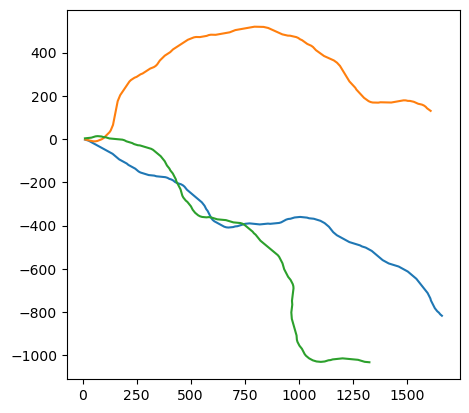

Average Reward:  0.08070828
Epoch 1/32, loss = 0.296044
Epoch 2/32, loss = 0.132624
Epoch 3/32, loss = 0.088733
Epoch 4/32, loss = 0.077817
Epoch 5/32, loss = 0.080612
Epoch 6/32, loss = 0.059155
Epoch 7/32, loss = 0.038650
Epoch 8/32, loss = 0.001604
Epoch 9/32, loss = 0.018520
Epoch 10/32, loss = 0.005143
Epoch 11/32, loss = 0.005644
Epoch 12/32, loss = 0.001889
Epoch 13/32, loss = 0.018171
Epoch 14/32, loss = 0.000164
Epoch 15/32, loss = 0.011250
Epoch 16/32, loss = 0.000249
Epoch 17/32, loss = 0.000116
Epoch 18/32, loss = 0.000284
Epoch 19/32, loss = 0.000062
Epoch 20/32, loss = 0.000277
Epoch 21/32, loss = 0.000041
Epoch 22/32, loss = 0.000093
Epoch 23/32, loss = 0.000133
Epoch 24/32, loss = 0.000604
Epoch 25/32, loss = 0.000076
Epoch 26/32, loss = 0.000251
Epoch 27/32, loss = 0.000086
Epoch 28/32, loss = 0.000266
Epoch 29/32, loss = 0.000167
Epoch 30/32, loss = 0.000389
Epoch 31/32, loss = 0.000552
Epoch 32/32, loss = 0.000652
Saved checkpoint at ./CheckpointsN=3/cycle_0.ckpt

==

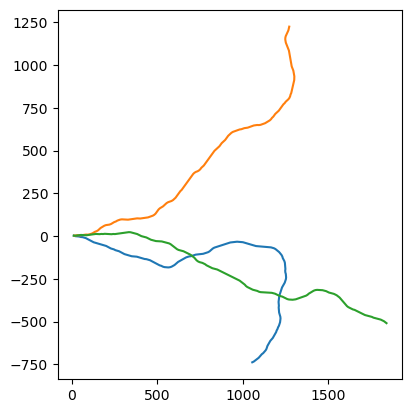

Average Reward:  0.1276316
Epoch 1/32, loss = 0.077981
Epoch 2/32, loss = 0.099182
Epoch 3/32, loss = 0.088452
Epoch 4/32, loss = 0.045611
Epoch 5/32, loss = 0.097419
Epoch 6/32, loss = 0.022799
Epoch 7/32, loss = 0.031142
Epoch 8/32, loss = 0.025450
Epoch 9/32, loss = 0.061317
Epoch 10/32, loss = 0.036503
Epoch 11/32, loss = 0.049992
Epoch 12/32, loss = 0.005661
Epoch 13/32, loss = 0.022630
Epoch 14/32, loss = 0.068150
Epoch 15/32, loss = 0.069939
Epoch 16/32, loss = 0.032347
Epoch 17/32, loss = 0.065294
Epoch 18/32, loss = 0.003130
Epoch 19/32, loss = 0.028829
Epoch 20/32, loss = 0.024996
Epoch 21/32, loss = 0.047438
Epoch 22/32, loss = 0.033285
Epoch 23/32, loss = 0.031731
Epoch 24/32, loss = 0.003402
Epoch 25/32, loss = 0.012241
Epoch 26/32, loss = 0.004230
Epoch 27/32, loss = 0.057349
Epoch 28/32, loss = 0.018004
Epoch 29/32, loss = 0.048497
Epoch 30/32, loss = 0.000855
Epoch 31/32, loss = 0.003371
Epoch 32/32, loss = 0.028411
Saved checkpoint at ./CheckpointsN=3/cycle_1.ckpt

===

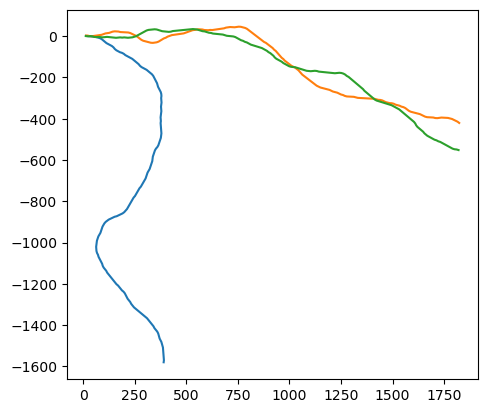

Average Reward:  0.20338115
Epoch 1/32, loss = 0.452368
Epoch 2/32, loss = 0.252223
Epoch 3/32, loss = 0.194830
Epoch 4/32, loss = 0.120419
Epoch 5/32, loss = 0.240276
Epoch 6/32, loss = 0.042123
Epoch 7/32, loss = 0.142444
Epoch 8/32, loss = 0.048904
Epoch 9/32, loss = 0.150135
Epoch 10/32, loss = 0.050794
Epoch 11/32, loss = 0.166911
Epoch 12/32, loss = 0.032225
Epoch 13/32, loss = 0.023206
Epoch 14/32, loss = 0.147625
Epoch 15/32, loss = 0.079143
Epoch 16/32, loss = 0.025168
Epoch 17/32, loss = 0.023916
Epoch 18/32, loss = 0.017713
Epoch 19/32, loss = 0.033638
Epoch 20/32, loss = 0.079215
Epoch 21/32, loss = 0.015610
Epoch 22/32, loss = 0.028819
Epoch 23/32, loss = 0.052314
Epoch 24/32, loss = 0.059767
Epoch 25/32, loss = 0.008702
Epoch 26/32, loss = 0.070607
Epoch 27/32, loss = 0.045308
Epoch 28/32, loss = 0.026503
Epoch 29/32, loss = 0.081027
Epoch 30/32, loss = 0.004049
Epoch 31/32, loss = 0.040615
Epoch 32/32, loss = 0.015868
Saved checkpoint at ./CheckpointsN=3/cycle_2.ckpt

==

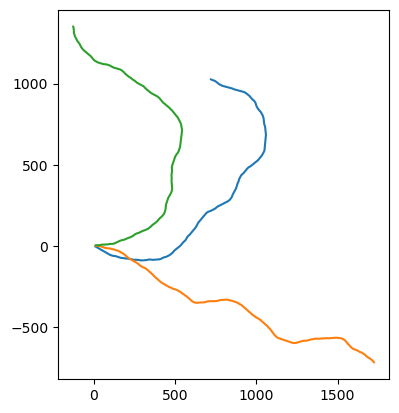

Average Reward:  0.1464141
Epoch 1/32, loss = 0.198753
Epoch 2/32, loss = 0.076640
Epoch 3/32, loss = 0.099563
Epoch 4/32, loss = 0.054505
Epoch 5/32, loss = 0.100016
Epoch 6/32, loss = 0.158179
Epoch 7/32, loss = 0.069079
Epoch 8/32, loss = 0.074390
Epoch 9/32, loss = 0.064339
Epoch 10/32, loss = 0.057305
Epoch 11/32, loss = 0.068971
Epoch 12/32, loss = 0.007711
Epoch 13/32, loss = 0.062492
Epoch 14/32, loss = 0.009063
Epoch 15/32, loss = 0.067943
Epoch 16/32, loss = 0.007861
Epoch 17/32, loss = 0.004437
Epoch 18/32, loss = 0.021971
Epoch 19/32, loss = 0.022693
Epoch 20/32, loss = 0.003302
Epoch 21/32, loss = 0.038038
Epoch 22/32, loss = 0.018498
Epoch 23/32, loss = 0.003310
Epoch 24/32, loss = 0.003512
Epoch 25/32, loss = 0.611378
Epoch 26/32, loss = 0.002956
Epoch 27/32, loss = 0.461374
Epoch 28/32, loss = 0.003353
Epoch 29/32, loss = 0.002351
Epoch 30/32, loss = 0.061438
Epoch 31/32, loss = 0.036503
Epoch 32/32, loss = 0.003421
Saved checkpoint at ./CheckpointsN=3/cycle_3.ckpt

===

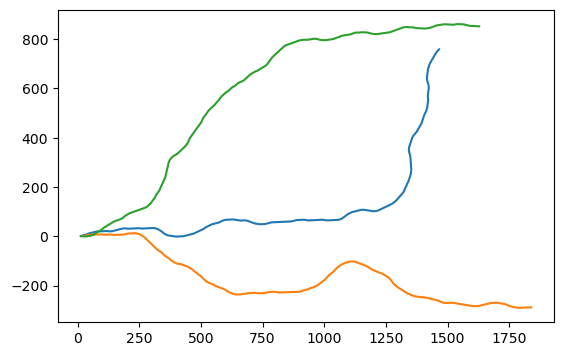

Average Reward:  0.16071616
Epoch 1/32, loss = 0.738892
Epoch 2/32, loss = 0.603360
Epoch 3/32, loss = 0.179257
Epoch 4/32, loss = 0.162410
Epoch 5/32, loss = 0.091319
Epoch 6/32, loss = 0.166662
Epoch 7/32, loss = 0.086503
Epoch 8/32, loss = 0.090325
Epoch 9/32, loss = 0.351445
Epoch 10/32, loss = 0.048379
Epoch 11/32, loss = 0.027505
Epoch 12/32, loss = 0.023096
Epoch 13/32, loss = 0.340699
Epoch 14/32, loss = 0.002631
Epoch 15/32, loss = 0.003080
Epoch 16/32, loss = 0.009433
Epoch 17/32, loss = 0.001039
Epoch 18/32, loss = 0.319228
Epoch 19/32, loss = 0.001799
Epoch 20/32, loss = 0.001003
Epoch 21/32, loss = 0.001585
Epoch 22/32, loss = 0.317150
Epoch 23/32, loss = 0.000823
Epoch 24/32, loss = 0.641033
Epoch 25/32, loss = 0.317797
Epoch 26/32, loss = 0.000697
Epoch 27/32, loss = 0.001867
Epoch 28/32, loss = 0.000809
Epoch 29/32, loss = 0.004803
Epoch 30/32, loss = 0.001801
Epoch 31/32, loss = 0.004163
Epoch 32/32, loss = 0.001315
Saved checkpoint at ./CheckpointsN=3/cycle_4.ckpt

==

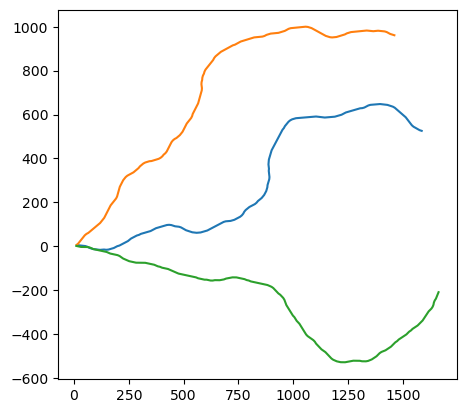

Average Reward:  0.1018216
Epoch 1/32, loss = 0.141704
Epoch 2/32, loss = 0.361569
Epoch 3/32, loss = 0.114880
Epoch 4/32, loss = 0.043448
Epoch 5/32, loss = 0.037706
Epoch 6/32, loss = 0.106875
Epoch 7/32, loss = 0.019822
Epoch 8/32, loss = 0.043121
Epoch 9/32, loss = 0.099425
Epoch 10/32, loss = 0.002314
Epoch 11/32, loss = 0.001246
Epoch 12/32, loss = 0.001245
Epoch 13/32, loss = 0.016329
Epoch 14/32, loss = 0.001449
Epoch 15/32, loss = 0.000410
Epoch 16/32, loss = 0.065527
Epoch 17/32, loss = 0.065546
Epoch 18/32, loss = 0.000602
Epoch 19/32, loss = 0.000218
Epoch 20/32, loss = 0.000220
Epoch 21/32, loss = 0.000338
Epoch 22/32, loss = 0.010193
Epoch 23/32, loss = 0.010184
Epoch 24/32, loss = 0.010086
Epoch 25/32, loss = 0.005274
Epoch 26/32, loss = 0.000208
Epoch 27/32, loss = 0.000227
Epoch 28/32, loss = 0.000247
Epoch 29/32, loss = 0.000208
Epoch 30/32, loss = 0.024446
Epoch 31/32, loss = 0.015184
Epoch 32/32, loss = 0.010065
Saved checkpoint at ./CheckpointsN=3/cycle_5.ckpt

===

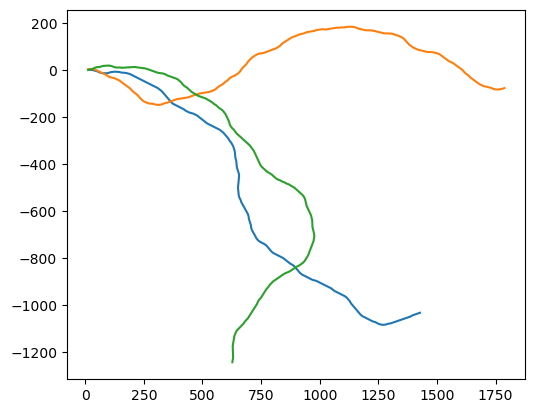

Average Reward:  0.21366447
Epoch 1/32, loss = 1.737309
Epoch 2/32, loss = 1.642578
Epoch 3/32, loss = 0.941807
Epoch 4/32, loss = 0.980315
Epoch 5/32, loss = 1.150173
Epoch 6/32, loss = 0.745692
Epoch 7/32, loss = 0.415780
Epoch 8/32, loss = 0.965555
Epoch 9/32, loss = 1.000768
Epoch 10/32, loss = 0.341727
Epoch 11/32, loss = 0.298903
Epoch 12/32, loss = 0.079535
Epoch 13/32, loss = 0.161847
Epoch 14/32, loss = 1.221101
Epoch 15/32, loss = 0.100885
Epoch 16/32, loss = 0.413937
Epoch 17/32, loss = 1.516420
Epoch 18/32, loss = 2.153381
Epoch 19/32, loss = 1.969328
Epoch 20/32, loss = 1.231124
Epoch 21/32, loss = 1.287009
Epoch 22/32, loss = 1.088334
Epoch 23/32, loss = 0.414432
Epoch 24/32, loss = 1.149240
Epoch 25/32, loss = 0.151605
Epoch 26/32, loss = 0.222914
Epoch 27/32, loss = 0.046122
Epoch 28/32, loss = 0.233204
Epoch 29/32, loss = 0.328292
Epoch 30/32, loss = 1.557800
Epoch 31/32, loss = 0.021782
Epoch 32/32, loss = 0.365295
Saved checkpoint at ./CheckpointsN=3/cycle_6.ckpt

==

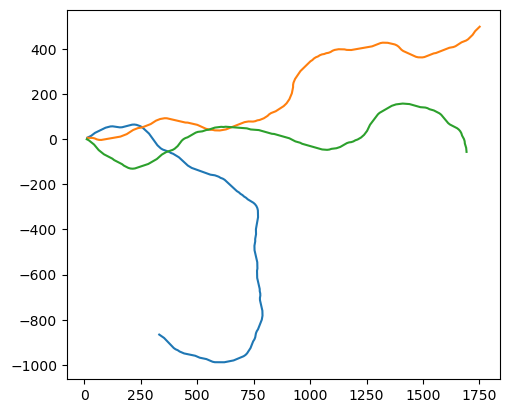

Average Reward:  0.11611084
Epoch 1/32, loss = 6.889663
Epoch 2/32, loss = 0.620845
Epoch 3/32, loss = 0.437451
Epoch 4/32, loss = 0.160387
Epoch 5/32, loss = 2.489584
Epoch 6/32, loss = 0.063140
Epoch 7/32, loss = 2.395377
Epoch 8/32, loss = 3.068901
Epoch 9/32, loss = 0.409314
Epoch 10/32, loss = 0.079166
Epoch 11/32, loss = 0.077625
Epoch 12/32, loss = 2.155131
Epoch 13/32, loss = 2.173969
Epoch 14/32, loss = 0.022027
Epoch 15/32, loss = 4.537385
Epoch 16/32, loss = 3.476234
Epoch 17/32, loss = 4.415884
Epoch 18/32, loss = 1.364063
Epoch 19/32, loss = 1.903154
Epoch 20/32, loss = 3.692519
Epoch 21/32, loss = 4.513337
Epoch 22/32, loss = 1.094950
Epoch 23/32, loss = 1.139867
Epoch 24/32, loss = 0.100043
Epoch 25/32, loss = 2.499433
Epoch 26/32, loss = 1.113208
Epoch 27/32, loss = 0.068278
Epoch 28/32, loss = 0.113198
Epoch 29/32, loss = 2.189468
Epoch 30/32, loss = 3.519969
Epoch 31/32, loss = 2.435325
Epoch 32/32, loss = 1.460210
Saved checkpoint at ./CheckpointsN=3/cycle_7.ckpt

==

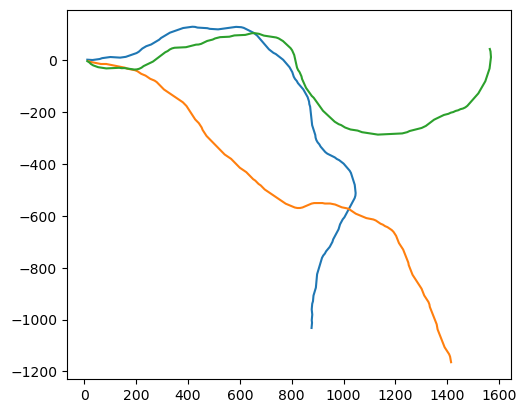

Average Reward:  0.2624816
Epoch 1/32, loss = 4.465522
Epoch 2/32, loss = 4.819304
Epoch 3/32, loss = 3.271951
Epoch 4/32, loss = 1.225572
Epoch 5/32, loss = 1.643995
Epoch 6/32, loss = 2.108401
Epoch 7/32, loss = 0.659632
Epoch 8/32, loss = 0.930102
Epoch 9/32, loss = 1.263942
Epoch 10/32, loss = 0.584719
Epoch 11/32, loss = 0.218257
Epoch 12/32, loss = 1.008454
Epoch 13/32, loss = 0.739157
Epoch 14/32, loss = 0.242090
Epoch 15/32, loss = 0.071491
Epoch 16/32, loss = 0.801237
Epoch 17/32, loss = 1.012906
Epoch 18/32, loss = 1.036787
Epoch 19/32, loss = 0.058466
Epoch 20/32, loss = 0.163412
Epoch 21/32, loss = 0.249906
Epoch 22/32, loss = 0.092477
Epoch 23/32, loss = 0.198967
Epoch 24/32, loss = 1.068262
Epoch 25/32, loss = 0.224024
Epoch 26/32, loss = 0.214136
Epoch 27/32, loss = 0.756986
Epoch 28/32, loss = 1.093268
Epoch 29/32, loss = 0.862759
Epoch 30/32, loss = 0.152396
Epoch 31/32, loss = 1.203694
Epoch 32/32, loss = 0.055124
Saved checkpoint at ./CheckpointsN=3/cycle_8.ckpt

===

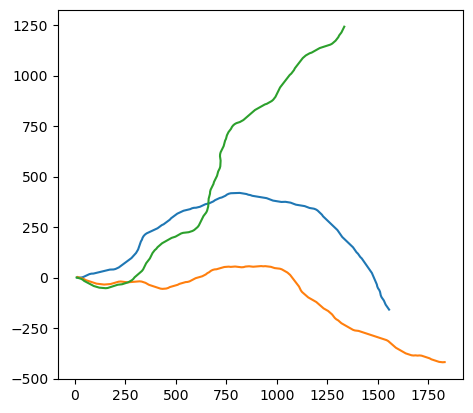

Average Reward:  0.15967639
Epoch 1/32, loss = 4.638330
Epoch 2/32, loss = 1.427883
Epoch 3/32, loss = 2.720699
Epoch 4/32, loss = 0.244728
Epoch 5/32, loss = 2.137785
Epoch 6/32, loss = 1.261792
Epoch 7/32, loss = 0.110198
Epoch 8/32, loss = 0.027693
Epoch 9/32, loss = 1.596042
Epoch 10/32, loss = 1.106725
Epoch 11/32, loss = 0.018275
Epoch 12/32, loss = 1.081509
Epoch 13/32, loss = 0.083819
Epoch 14/32, loss = 0.042802
Epoch 15/32, loss = 0.023132
Epoch 16/32, loss = 3.343144
Epoch 17/32, loss = 0.042876
Epoch 18/32, loss = 1.489118
Epoch 19/32, loss = 0.871482
Epoch 20/32, loss = 0.020379
Epoch 21/32, loss = 1.078517
Epoch 22/32, loss = 3.049807
Epoch 23/32, loss = 0.020930
Epoch 24/32, loss = 0.017922
Epoch 25/32, loss = 0.015842
Epoch 26/32, loss = 1.580894
Epoch 27/32, loss = 1.061548
Epoch 28/32, loss = 1.060880
Epoch 29/32, loss = 0.060898
Epoch 30/32, loss = 2.521487
Epoch 31/32, loss = 0.031882
Epoch 32/32, loss = 1.500165
Saved checkpoint at ./CheckpointsN=3/cycle_9.ckpt

==

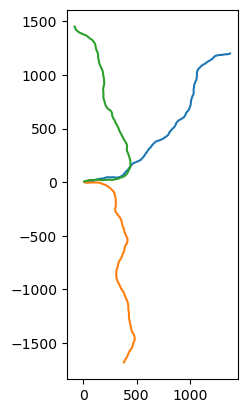

Average Reward:  0.31767488
Epoch 1/32, loss = 5.482617
Epoch 2/32, loss = 2.411455
Epoch 3/32, loss = 1.216317
Epoch 4/32, loss = 1.912769
Epoch 5/32, loss = 0.830072
Epoch 6/32, loss = 0.369313
Epoch 7/32, loss = 0.365092
Epoch 8/32, loss = 0.166284
Epoch 9/32, loss = 0.177047
Epoch 10/32, loss = 0.070683
Epoch 11/32, loss = 0.162643
Epoch 12/32, loss = 0.123603
Epoch 13/32, loss = 5.875156
Epoch 14/32, loss = 0.073854
Epoch 15/32, loss = 0.183901
Epoch 16/32, loss = 0.024480
Epoch 17/32, loss = 0.127033
Epoch 18/32, loss = 0.030684
Epoch 19/32, loss = 0.066075
Epoch 20/32, loss = 0.018554
Epoch 21/32, loss = 5.487602
Epoch 22/32, loss = 0.021360
Epoch 23/32, loss = 0.060090
Epoch 24/32, loss = 0.089422
Epoch 25/32, loss = 5.877174
Epoch 26/32, loss = 0.041795
Epoch 27/32, loss = 5.808819
Epoch 28/32, loss = 0.014689
Epoch 29/32, loss = 0.050660
Epoch 30/32, loss = 0.056319
Epoch 31/32, loss = 0.061220
Epoch 32/32, loss = 0.014097
Saved checkpoint at ./CheckpointsN=3/cycle_10.ckpt

=

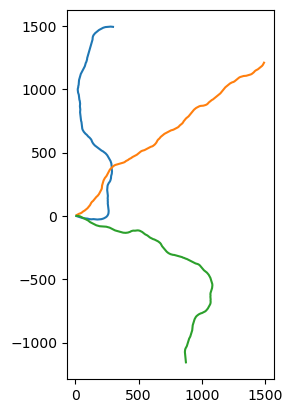

Average Reward:  0.078698814
Epoch 1/32, loss = 0.227749
Epoch 2/32, loss = 1.187240
Epoch 3/32, loss = 0.528992
Epoch 4/32, loss = 0.553021
Epoch 5/32, loss = 0.822414
Epoch 6/32, loss = 0.106356
Epoch 7/32, loss = 0.234309
Epoch 8/32, loss = 0.449340
Epoch 9/32, loss = 0.042974
Epoch 10/32, loss = 0.008112
Epoch 11/32, loss = 0.102808
Epoch 12/32, loss = 0.088249
Epoch 13/32, loss = 0.017333
Epoch 14/32, loss = 0.011029
Epoch 15/32, loss = 0.070474
Epoch 16/32, loss = 0.041099
Epoch 17/32, loss = 0.034980
Epoch 18/32, loss = 0.001977
Epoch 19/32, loss = 0.004006
Epoch 20/32, loss = 0.004575
Epoch 21/32, loss = 0.003118
Epoch 22/32, loss = 0.030023
Epoch 23/32, loss = 0.001395
Epoch 24/32, loss = 0.001954
Epoch 25/32, loss = 0.003974
Epoch 26/32, loss = 0.000620
Epoch 27/32, loss = 0.000715
Epoch 28/32, loss = 0.031241
Epoch 29/32, loss = 0.000925
Epoch 30/32, loss = 0.388128
Epoch 31/32, loss = 0.387925
Epoch 32/32, loss = 0.001172
Saved checkpoint at ./CheckpointsN=3/cycle_11.ckpt



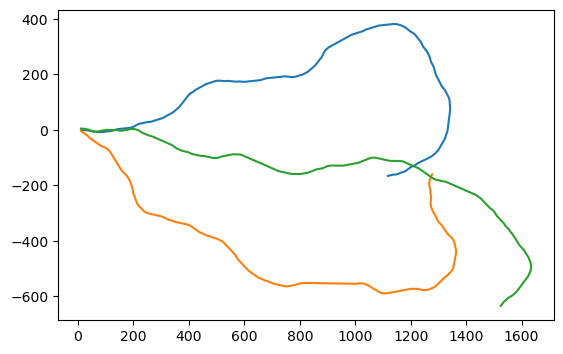

Average Reward:  0.13686843
Epoch 1/32, loss = 5.633324
Epoch 2/32, loss = 1.117952
Epoch 3/32, loss = 2.260435
Epoch 4/32, loss = 1.422546
Epoch 5/32, loss = 0.338408
Epoch 6/32, loss = 0.105712
Epoch 7/32, loss = 0.209788
Epoch 8/32, loss = 0.024137
Epoch 9/32, loss = 0.099976
Epoch 10/32, loss = 0.163865
Epoch 11/32, loss = 0.020679
Epoch 12/32, loss = 0.007096
Epoch 13/32, loss = 0.002551
Epoch 14/32, loss = 0.068465
Epoch 15/32, loss = 0.008553
Epoch 16/32, loss = 0.021671
Epoch 17/32, loss = 0.005150
Epoch 18/32, loss = 0.002278
Epoch 19/32, loss = 0.022823
Epoch 20/32, loss = 0.008901
Epoch 21/32, loss = 0.022220
Epoch 22/32, loss = 0.018266
Epoch 23/32, loss = 0.018670
Epoch 24/32, loss = 0.004071
Epoch 25/32, loss = 0.005805
Epoch 26/32, loss = 0.035265
Epoch 27/32, loss = 0.021983
Epoch 28/32, loss = 0.034015
Epoch 29/32, loss = 0.031326
Epoch 30/32, loss = 0.005092
Epoch 31/32, loss = 0.062186
Epoch 32/32, loss = 0.006538
Saved checkpoint at ./CheckpointsN=3/cycle_12.ckpt

=

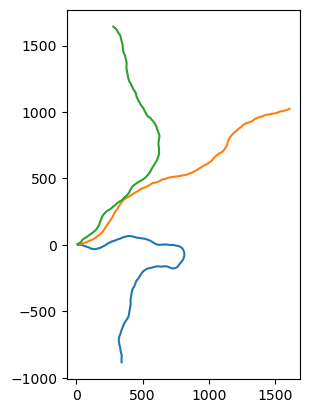

Average Reward:  0.1458498
Epoch 1/32, loss = 2.323871
Epoch 2/32, loss = 3.465928
Epoch 3/32, loss = 0.574713
Epoch 4/32, loss = 4.035615
Epoch 5/32, loss = 0.696405
Epoch 6/32, loss = 3.770086
Epoch 7/32, loss = 0.460114
Epoch 8/32, loss = 0.298276
Epoch 9/32, loss = 4.113399
Epoch 10/32, loss = 4.394755
Epoch 11/32, loss = 0.435276
Epoch 12/32, loss = 0.202659
Epoch 13/32, loss = 0.097156
Epoch 14/32, loss = 2.923747
Epoch 15/32, loss = 0.138218
Epoch 16/32, loss = 0.067770
Epoch 17/32, loss = 0.059416
Epoch 18/32, loss = 0.068198
Epoch 19/32, loss = 7.130428
Epoch 20/32, loss = 2.883850
Epoch 21/32, loss = 3.236942
Epoch 22/32, loss = 0.013765
Epoch 23/32, loss = 0.086894
Epoch 24/32, loss = 0.025773
Epoch 25/32, loss = 0.055092
Epoch 26/32, loss = 8.148461
Epoch 27/32, loss = 0.040288
Epoch 28/32, loss = 0.076288
Epoch 29/32, loss = 0.054947
Epoch 30/32, loss = 0.049679
Epoch 31/32, loss = 0.165220
Epoch 32/32, loss = 2.830389
Saved checkpoint at ./CheckpointsN=3/cycle_13.ckpt

==

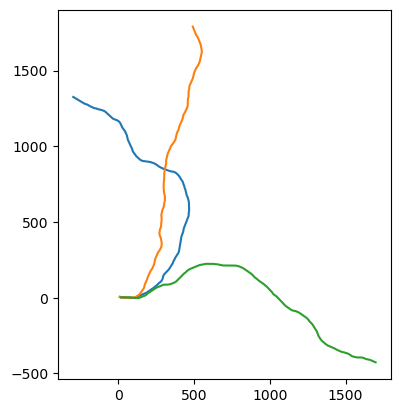

Average Reward:  0.25148574
Epoch 1/32, loss = 13.609477
Epoch 2/32, loss = 5.060173
Epoch 3/32, loss = 3.153231
Epoch 4/32, loss = 0.369513
Epoch 5/32, loss = 0.915082
Epoch 6/32, loss = 0.979397
Epoch 7/32, loss = 0.516734
Epoch 8/32, loss = 0.826431
Epoch 9/32, loss = 2.964742
Epoch 10/32, loss = 1.684813
Epoch 11/32, loss = 0.241681
Epoch 12/32, loss = 0.164722
Epoch 13/32, loss = 0.173265
Epoch 14/32, loss = 0.062336
Epoch 15/32, loss = 0.044501
Epoch 16/32, loss = 0.092775
Epoch 17/32, loss = 0.105883
Epoch 18/32, loss = 0.037665
Epoch 19/32, loss = 0.051120
Epoch 20/32, loss = 1.471718
Epoch 21/32, loss = 1.485582
Epoch 22/32, loss = 0.063556
Epoch 23/32, loss = 0.028728
Epoch 24/32, loss = 1.403841
Epoch 25/32, loss = 0.012998
Epoch 26/32, loss = 1.402495
Epoch 27/32, loss = 0.005333
Epoch 28/32, loss = 0.012502
Epoch 29/32, loss = 0.008807
Epoch 30/32, loss = 0.011643
Epoch 31/32, loss = 0.008822
Epoch 32/32, loss = 1.387603
Saved checkpoint at ./CheckpointsN=3/cycle_14.ckpt



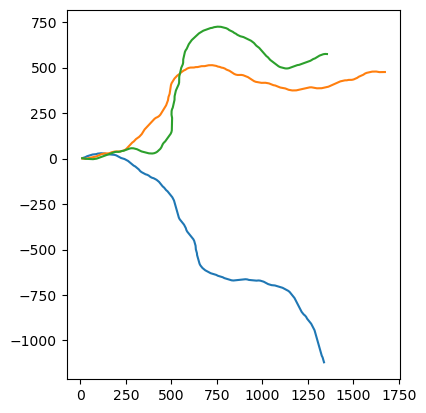

Average Reward:  0.22468244
Epoch 1/32, loss = 37.377022
Epoch 2/32, loss = 20.270220
Epoch 3/32, loss = 6.179116
Epoch 4/32, loss = 5.315210
Epoch 5/32, loss = 2.703915
Epoch 6/32, loss = 2.180255
Epoch 7/32, loss = 2.055063
Epoch 8/32, loss = 2.010051
Epoch 9/32, loss = 0.919735
Epoch 10/32, loss = 1.178444
Epoch 11/32, loss = 0.163799
Epoch 12/32, loss = 0.038413
Epoch 13/32, loss = 0.076825
Epoch 14/32, loss = 0.020036
Epoch 15/32, loss = 0.063004
Epoch 16/32, loss = 1.066548
Epoch 17/32, loss = 0.126301
Epoch 18/32, loss = 1.053598
Epoch 19/32, loss = 0.022706
Epoch 20/32, loss = 0.007973
Epoch 21/32, loss = 0.111327
Epoch 22/32, loss = 1.041425
Epoch 23/32, loss = 0.013196
Epoch 24/32, loss = 0.042228
Epoch 25/32, loss = 0.013556
Epoch 26/32, loss = 0.103960
Epoch 27/32, loss = 0.053517
Epoch 28/32, loss = 0.006281
Epoch 29/32, loss = 0.020640
Epoch 30/32, loss = 0.022503
Epoch 31/32, loss = 0.057608
Epoch 32/32, loss = 0.006944
Saved checkpoint at ./CheckpointsN=3/cycle_15.ckpt


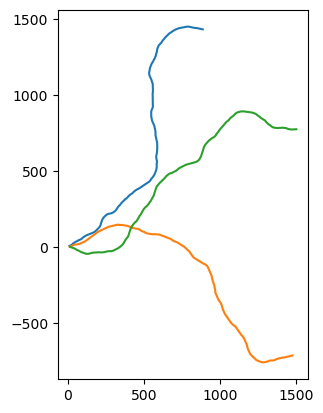

Average Reward:  0.12578061
Epoch 1/32, loss = 10.590054
Epoch 2/32, loss = 9.488618
Epoch 3/32, loss = 2.143010
Epoch 4/32, loss = 1.138270
Epoch 5/32, loss = 0.712210
Epoch 6/32, loss = 0.484660
Epoch 7/32, loss = 0.383324
Epoch 8/32, loss = 0.055893
Epoch 9/32, loss = 0.126884
Epoch 10/32, loss = 0.037786
Epoch 11/32, loss = 0.024952
Epoch 12/32, loss = 0.022640
Epoch 13/32, loss = 0.006257
Epoch 14/32, loss = 0.030160
Epoch 15/32, loss = 0.014671
Epoch 16/32, loss = 0.005608
Epoch 17/32, loss = 0.003365
Epoch 18/32, loss = 0.006740
Epoch 19/32, loss = 0.003749
Epoch 20/32, loss = 0.005631
Epoch 21/32, loss = 0.032580
Epoch 22/32, loss = 0.011046
Epoch 23/32, loss = 0.008508
Epoch 24/32, loss = 0.003608
Epoch 25/32, loss = 0.015442
Epoch 26/32, loss = 0.004798
Epoch 27/32, loss = 0.017415
Epoch 28/32, loss = 0.017153
Epoch 29/32, loss = 0.009287
Epoch 30/32, loss = 0.012435
Epoch 31/32, loss = 0.013258
Epoch 32/32, loss = 0.028606
Saved checkpoint at ./CheckpointsN=3/cycle_16.ckpt



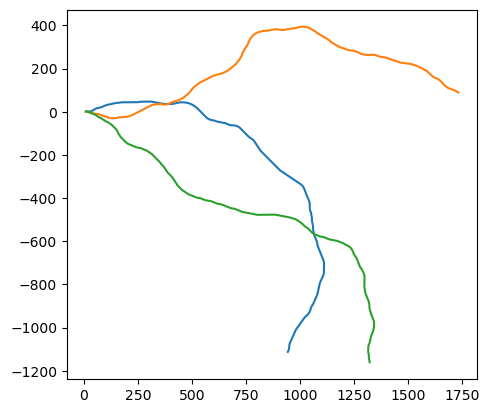

Average Reward:  0.19470719
Epoch 1/32, loss = 10.672005
Epoch 2/32, loss = 2.097123
Epoch 3/32, loss = 21.415661
Epoch 4/32, loss = 2.780846
Epoch 5/32, loss = 0.738132
Epoch 6/32, loss = 0.279305
Epoch 7/32, loss = 0.384806
Epoch 8/32, loss = 0.553618
Epoch 9/32, loss = 9.703264
Epoch 10/32, loss = 0.256338
Epoch 11/32, loss = 0.209953
Epoch 12/32, loss = 0.386184
Epoch 13/32, loss = 9.442976
Epoch 14/32, loss = 0.127905
Epoch 15/32, loss = 0.091743
Epoch 16/32, loss = 0.250830
Epoch 17/32, loss = 0.132405
Epoch 18/32, loss = 9.527553
Epoch 19/32, loss = 15.331372
Epoch 20/32, loss = 0.113868
Epoch 21/32, loss = 9.618917
Epoch 22/32, loss = 0.160262
Epoch 23/32, loss = 0.255253
Epoch 24/32, loss = 0.217888
Epoch 25/32, loss = 0.201903
Epoch 26/32, loss = 0.225457
Epoch 27/32, loss = 0.225474
Epoch 28/32, loss = 0.194383
Epoch 29/32, loss = 0.215016
Epoch 30/32, loss = 9.428313
Epoch 31/32, loss = 9.588583
Epoch 32/32, loss = 0.092971
Saved checkpoint at ./CheckpointsN=3/cycle_17.ckpt

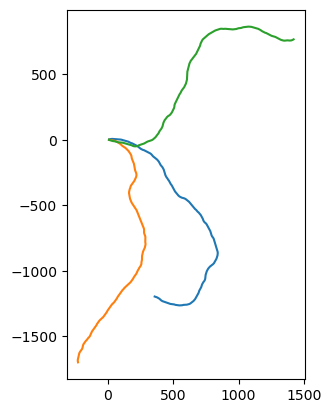

Average Reward:  0.17196919
Epoch 1/32, loss = 40.298409
Epoch 2/32, loss = 6.166482
Epoch 3/32, loss = 14.803138
Epoch 4/32, loss = 6.954544
Epoch 5/32, loss = 5.835676
Epoch 6/32, loss = 3.272146
Epoch 7/32, loss = 2.789151
Epoch 8/32, loss = 4.031619
Epoch 9/32, loss = 2.780097
Epoch 10/32, loss = 1.431552
Epoch 11/32, loss = 0.485345
Epoch 12/32, loss = 0.492505
Epoch 13/32, loss = 0.154642
Epoch 14/32, loss = 1.266370
Epoch 15/32, loss = 14.658137
Epoch 16/32, loss = 0.203460
Epoch 17/32, loss = 0.062532
Epoch 18/32, loss = 0.042873
Epoch 19/32, loss = 0.081296
Epoch 20/32, loss = 0.594430
Epoch 21/32, loss = 0.136052
Epoch 22/32, loss = 0.407772
Epoch 23/32, loss = 0.162647
Epoch 24/32, loss = 19.915688
Epoch 25/32, loss = 0.342347
Epoch 26/32, loss = 0.070943
Epoch 27/32, loss = 0.205233
Epoch 28/32, loss = 19.812405
Epoch 29/32, loss = 0.076521
Epoch 30/32, loss = 0.133601
Epoch 31/32, loss = 0.048482
Epoch 32/32, loss = 0.045221
Saved checkpoint at ./CheckpointsN=3/cycle_18.ck

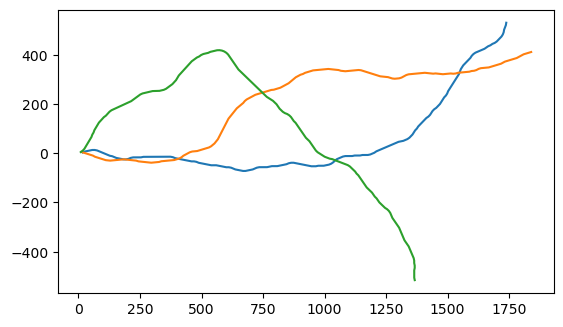

Average Reward:  0.24951401
Epoch 1/32, loss = 29.947197
Epoch 2/32, loss = 22.312073
Epoch 3/32, loss = 18.844172
Epoch 4/32, loss = 14.056534
Epoch 5/32, loss = 9.614419
Epoch 6/32, loss = 4.395139
Epoch 7/32, loss = 20.124987
Epoch 8/32, loss = 2.657072
Epoch 9/32, loss = 13.161165
Epoch 10/32, loss = 0.566752
Epoch 11/32, loss = 0.991159
Epoch 12/32, loss = 0.882831
Epoch 13/32, loss = 0.288493
Epoch 14/32, loss = 0.695599
Epoch 15/32, loss = 0.674964
Epoch 16/32, loss = 0.549065
Epoch 17/32, loss = 0.540186
Epoch 18/32, loss = 17.552990
Epoch 19/32, loss = 0.237196
Epoch 20/32, loss = 0.218116
Epoch 21/32, loss = 0.334283
Epoch 22/32, loss = 18.105125
Epoch 23/32, loss = 0.209898
Epoch 24/32, loss = 0.205040
Epoch 25/32, loss = 0.358457
Epoch 26/32, loss = 28.077339
Epoch 27/32, loss = 10.884764
Epoch 28/32, loss = 17.535446
Epoch 29/32, loss = 10.636375
Epoch 30/32, loss = 0.339842
Epoch 31/32, loss = 0.250350
Epoch 32/32, loss = 0.111841
Saved checkpoint at ./CheckpointsN=3/cycl

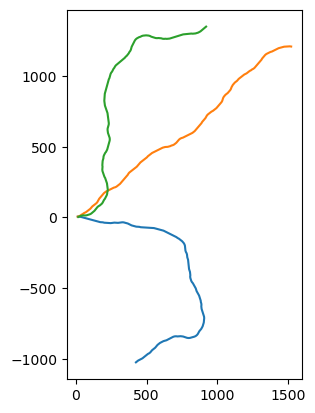

Average Reward:  0.15086517
Epoch 1/32, loss = 21.983685
Epoch 2/32, loss = 5.750456
Epoch 3/32, loss = 10.881771
Epoch 4/32, loss = 5.709591
Epoch 5/32, loss = 5.463836
Epoch 6/32, loss = 14.338782
Epoch 7/32, loss = 5.071049
Epoch 8/32, loss = 3.210172
Epoch 9/32, loss = 1.645577
Epoch 10/32, loss = 11.494584
Epoch 11/32, loss = 1.810165
Epoch 12/32, loss = 0.066663
Epoch 13/32, loss = 0.450746
Epoch 14/32, loss = 1.843167
Epoch 15/32, loss = 0.539957
Epoch 16/32, loss = 11.588764
Epoch 17/32, loss = 14.194435
Epoch 18/32, loss = 13.913900
Epoch 19/32, loss = 0.647196
Epoch 20/32, loss = 0.390724
Epoch 21/32, loss = 10.823720
Epoch 22/32, loss = 0.105939
Epoch 23/32, loss = 20.878199
Epoch 24/32, loss = 6.864263
Epoch 25/32, loss = 10.758208
Epoch 26/32, loss = 6.912030
Epoch 27/32, loss = 0.076074
Epoch 28/32, loss = 10.085817
Epoch 29/32, loss = 0.113957
Epoch 30/32, loss = 0.171841
Epoch 31/32, loss = 10.686804
Epoch 32/32, loss = 13.885643
Saved checkpoint at ./CheckpointsN=3/cyc

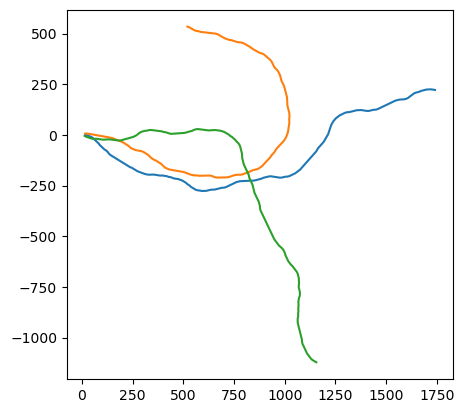

Average Reward:  0.18516745
Epoch 1/32, loss = 73.558578
Epoch 2/32, loss = 32.901619
Epoch 3/32, loss = 1.544244
Epoch 4/32, loss = 28.599707
Epoch 5/32, loss = 24.184750
Epoch 6/32, loss = 15.505219
Epoch 7/32, loss = 23.765329
Epoch 8/32, loss = 0.834038
Epoch 9/32, loss = 32.563862
Epoch 10/32, loss = 0.358375
Epoch 11/32, loss = 0.848118
Epoch 12/32, loss = 81.933434
Epoch 13/32, loss = 31.767750
Epoch 14/32, loss = 34.262005
Epoch 15/32, loss = 57.734215
Epoch 16/32, loss = 46.219814
Epoch 17/32, loss = 2.889395
Epoch 18/32, loss = 0.245767
Epoch 19/32, loss = 28.371977
Epoch 20/32, loss = 2.620146
Epoch 21/32, loss = 24.597410
Epoch 22/32, loss = 0.380062
Epoch 23/32, loss = 28.007013
Epoch 24/32, loss = 2.186681
Epoch 25/32, loss = 47.637230
Epoch 26/32, loss = 2.684114
Epoch 27/32, loss = 0.271930
Epoch 28/32, loss = 2.638712
Epoch 29/32, loss = 0.357455
Epoch 30/32, loss = 24.635256
Epoch 31/32, loss = 2.569649
Epoch 32/32, loss = 21.831299
Saved checkpoint at ./CheckpointsN=

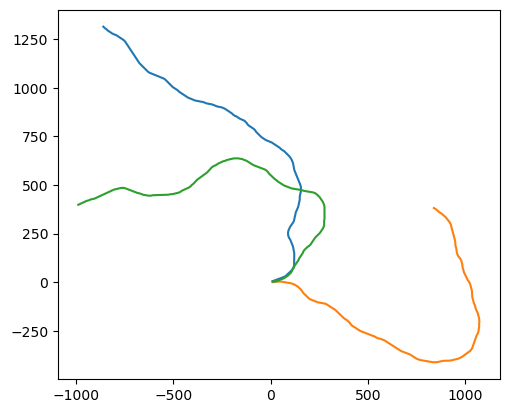

Average Reward:  0.13334551
Epoch 1/32, loss = 16.412958
Epoch 2/32, loss = 10.335426
Epoch 3/32, loss = 1.938926
Epoch 4/32, loss = 0.601940
Epoch 5/32, loss = 0.131550
Epoch 6/32, loss = 0.470140
Epoch 7/32, loss = 4.381652
Epoch 8/32, loss = 0.059587
Epoch 9/32, loss = 0.663175
Epoch 10/32, loss = 3.340037
Epoch 11/32, loss = 3.012323
Epoch 12/32, loss = 0.623472
Epoch 13/32, loss = 0.538133
Epoch 14/32, loss = 0.220371
Epoch 15/32, loss = 0.007839
Epoch 16/32, loss = 2.558263
Epoch 17/32, loss = 0.176337
Epoch 18/32, loss = 0.759511
Epoch 19/32, loss = 2.320876
Epoch 20/32, loss = 0.015467
Epoch 21/32, loss = 0.624937
Epoch 22/32, loss = 0.013145
Epoch 23/32, loss = 0.036464
Epoch 24/32, loss = 0.137724
Epoch 25/32, loss = 0.058031
Epoch 26/32, loss = 0.125756
Epoch 27/32, loss = 0.028879
Epoch 28/32, loss = 0.009337
Epoch 29/32, loss = 0.265781
Epoch 30/32, loss = 0.017379
Epoch 31/32, loss = 0.002334
Epoch 32/32, loss = 0.013621
Saved checkpoint at ./CheckpointsN=3/cycle_22.ckpt


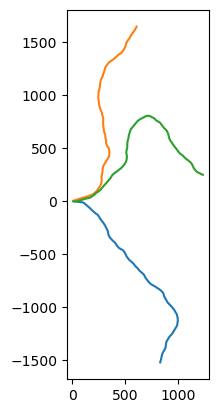

Average Reward:  0.18324709
Epoch 1/32, loss = 5.429660
Epoch 2/32, loss = 8.496846
Epoch 3/32, loss = 2.944627
Epoch 4/32, loss = 3.149965
Epoch 5/32, loss = 1.751537
Epoch 6/32, loss = 1.787147
Epoch 7/32, loss = 0.606930
Epoch 8/32, loss = 1.037800
Epoch 9/32, loss = 2.058425
Epoch 10/32, loss = 1.444113
Epoch 11/32, loss = 0.057026
Epoch 12/32, loss = 0.056985
Epoch 13/32, loss = 0.070884
Epoch 14/32, loss = 0.118702
Epoch 15/32, loss = 0.029874
Epoch 16/32, loss = 0.988770
Epoch 17/32, loss = 0.786366
Epoch 18/32, loss = 0.051544
Epoch 19/32, loss = 0.726538
Epoch 20/32, loss = 0.779123
Epoch 21/32, loss = 0.034192
Epoch 22/32, loss = 0.074996
Epoch 23/32, loss = 0.998613
Epoch 24/32, loss = 0.585388
Epoch 25/32, loss = 0.148694
Epoch 26/32, loss = 1.214121
Epoch 27/32, loss = 0.696058
Epoch 28/32, loss = 0.901348
Epoch 29/32, loss = 0.055709
Epoch 30/32, loss = 0.152454
Epoch 31/32, loss = 0.016983
Epoch 32/32, loss = 0.162929
Saved checkpoint at ./CheckpointsN=3/cycle_23.ckpt

=

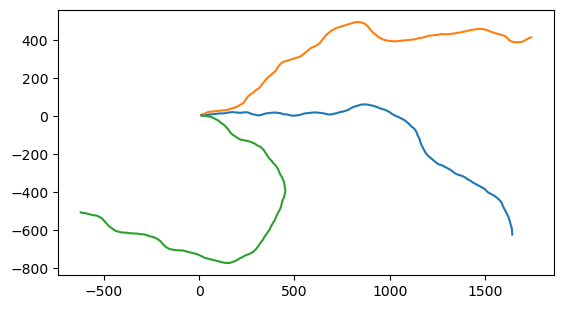

Average Reward:  0.11451106
Epoch 1/32, loss = 20.226162
Epoch 2/32, loss = 12.794773
Epoch 3/32, loss = 2.662056
Epoch 4/32, loss = 2.804320
Epoch 5/32, loss = 1.004650
Epoch 6/32, loss = 0.760982
Epoch 7/32, loss = 0.265046
Epoch 8/32, loss = 1.100417
Epoch 9/32, loss = 0.555589
Epoch 10/32, loss = 0.165773
Epoch 11/32, loss = 0.322857
Epoch 12/32, loss = 1.147354
Epoch 13/32, loss = 0.283425
Epoch 14/32, loss = 0.129333
Epoch 15/32, loss = 0.047354
Epoch 16/32, loss = 10.020164
Epoch 17/32, loss = 0.390842
Epoch 18/32, loss = 0.075890
Epoch 19/32, loss = 17.516741
Epoch 20/32, loss = 0.116455
Epoch 21/32, loss = 9.798537
Epoch 22/32, loss = 0.030255
Epoch 23/32, loss = 7.521089
Epoch 24/32, loss = 0.238547
Epoch 25/32, loss = 0.200857
Epoch 26/32, loss = 7.530470
Epoch 27/32, loss = 9.945266
Epoch 28/32, loss = 0.059301
Epoch 29/32, loss = 9.825839
Epoch 30/32, loss = 7.518105
Epoch 31/32, loss = 0.017755
Epoch 32/32, loss = 0.012460
Saved checkpoint at ./CheckpointsN=3/cycle_24.ckp

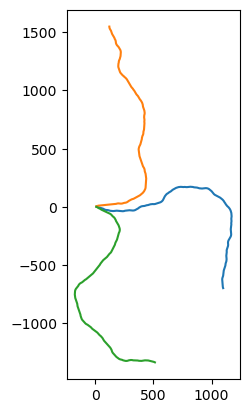

Average Reward:  0.09379408
Epoch 1/32, loss = 7.918931
Epoch 2/32, loss = 16.494774
Epoch 3/32, loss = 9.108304
Epoch 4/32, loss = 5.365765
Epoch 5/32, loss = 5.008369
Epoch 6/32, loss = 0.207234
Epoch 7/32, loss = 8.185868
Epoch 8/32, loss = 2.996449
Epoch 9/32, loss = 4.180629
Epoch 10/32, loss = 1.192907
Epoch 11/32, loss = 0.563904
Epoch 12/32, loss = 0.504996
Epoch 13/32, loss = 0.212551
Epoch 14/32, loss = 0.663097
Epoch 15/32, loss = 1.323494
Epoch 16/32, loss = 0.215813
Epoch 17/32, loss = 0.024309
Epoch 18/32, loss = 0.024389
Epoch 19/32, loss = 0.716457
Epoch 20/32, loss = 0.005878
Epoch 21/32, loss = 0.612508
Epoch 22/32, loss = 0.372303
Epoch 23/32, loss = 0.012822
Epoch 24/32, loss = 0.158647
Epoch 25/32, loss = 0.060307
Epoch 26/32, loss = 0.364557
Epoch 27/32, loss = 0.220120
Epoch 28/32, loss = 0.020793
Epoch 29/32, loss = 0.003354
Epoch 30/32, loss = 0.007970
Epoch 31/32, loss = 0.109140
Epoch 32/32, loss = 0.007480
Saved checkpoint at ./CheckpointsN=3/cycle_25.ckpt



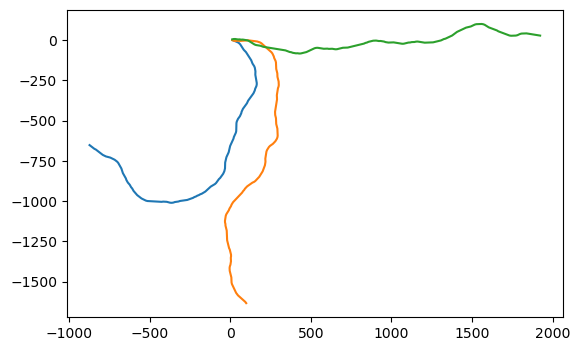

Average Reward:  0.14961411
Epoch 1/32, loss = 10.434921
Epoch 2/32, loss = 6.887566
Epoch 3/32, loss = 2.919174
Epoch 4/32, loss = 3.176594
Epoch 5/32, loss = 0.807695
Epoch 6/32, loss = 0.594079
Epoch 7/32, loss = 0.620283
Epoch 8/32, loss = 0.105128
Epoch 9/32, loss = 1.247590
Epoch 10/32, loss = 0.362503
Epoch 11/32, loss = 0.110268
Epoch 12/32, loss = 0.063665
Epoch 13/32, loss = 0.214530
Epoch 14/32, loss = 0.073430
Epoch 15/32, loss = 0.044349
Epoch 16/32, loss = 0.067659
Epoch 17/32, loss = 0.059817
Epoch 18/32, loss = 0.109003
Epoch 19/32, loss = 0.003730
Epoch 20/32, loss = 2.339009
Epoch 21/32, loss = 0.021560
Epoch 22/32, loss = 0.002627
Epoch 23/32, loss = 0.052390
Epoch 24/32, loss = 0.004501
Epoch 25/32, loss = 0.002315
Epoch 26/32, loss = 0.071195
Epoch 27/32, loss = 0.015187
Epoch 28/32, loss = 0.961561
Epoch 29/32, loss = 2.405177
Epoch 30/32, loss = 0.013131
Epoch 31/32, loss = 0.016262
Epoch 32/32, loss = 0.006080
Saved checkpoint at ./CheckpointsN=3/cycle_26.ckpt



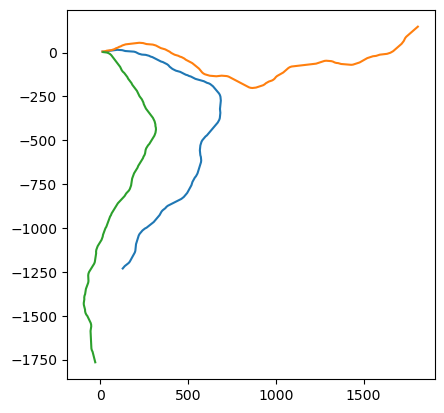

Average Reward:  0.08137392
Epoch 1/32, loss = 21.568203
Epoch 2/32, loss = 1.872801
Epoch 3/32, loss = 1.068246
Epoch 4/32, loss = 0.412637
Epoch 5/32, loss = 0.113147
Epoch 6/32, loss = 0.114250
Epoch 7/32, loss = 0.080684
Epoch 8/32, loss = 0.023015
Epoch 9/32, loss = 0.037491
Epoch 10/32, loss = 0.005501
Epoch 11/32, loss = 0.001608
Epoch 12/32, loss = 0.001210
Epoch 13/32, loss = 0.001109
Epoch 14/32, loss = 0.013828
Epoch 15/32, loss = 0.009074
Epoch 16/32, loss = 0.000322
Epoch 17/32, loss = 0.001186
Epoch 18/32, loss = 0.000205
Epoch 19/32, loss = 0.000152
Epoch 20/32, loss = 0.021777
Epoch 21/32, loss = 0.009927
Epoch 22/32, loss = 0.008622
Epoch 23/32, loss = 0.008709
Epoch 24/32, loss = 0.001663
Epoch 25/32, loss = 0.000572
Epoch 26/32, loss = 0.008397
Epoch 27/32, loss = 0.025385
Epoch 28/32, loss = 0.009610
Epoch 29/32, loss = 0.015854
Epoch 30/32, loss = 0.001238
Epoch 31/32, loss = 0.000164
Epoch 32/32, loss = 0.000599
Saved checkpoint at ./CheckpointsN=3/cycle_27.ckpt



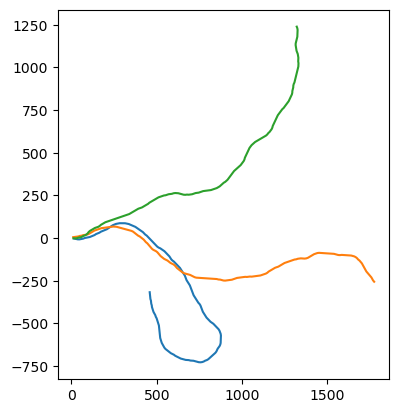

Average Reward:  0.4056859
Epoch 1/32, loss = 104.014702
Epoch 2/32, loss = 24.402351
Epoch 3/32, loss = 31.874763
Epoch 4/32, loss = 12.014261
Epoch 5/32, loss = 38.047165
Epoch 6/32, loss = 3.042736
Epoch 7/32, loss = 6.462690
Epoch 8/32, loss = 10.728669
Epoch 9/32, loss = 4.548799
Epoch 10/32, loss = 6.784894
Epoch 11/32, loss = 4.804182
Epoch 12/32, loss = 6.332928
Epoch 13/32, loss = 7.395649
Epoch 14/32, loss = 9.001795
Epoch 15/32, loss = 8.691970
Epoch 16/32, loss = 3.851945
Epoch 17/32, loss = 3.293535
Epoch 18/32, loss = 7.009902
Epoch 19/32, loss = 1.991283
Epoch 20/32, loss = 3.819756
Epoch 21/32, loss = 5.107167
Epoch 22/32, loss = 1.748691
Epoch 23/32, loss = 7.054226
Epoch 24/32, loss = 2.273510
Epoch 25/32, loss = 2.475744
Epoch 26/32, loss = 23.871231
Epoch 27/32, loss = 20.001427
Epoch 28/32, loss = 6.344131
Epoch 29/32, loss = 1.671858
Epoch 30/32, loss = 3.845324
Epoch 31/32, loss = 0.873335
Epoch 32/32, loss = 0.880551
Saved checkpoint at ./CheckpointsN=3/cycle_28

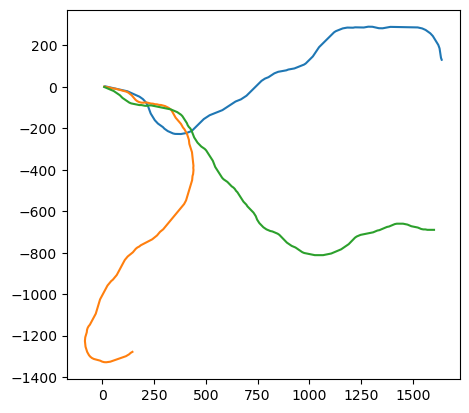

Average Reward:  0.3671878
Epoch 1/32, loss = 42.581703
Epoch 2/32, loss = 18.702972
Epoch 3/32, loss = 36.726055
Epoch 4/32, loss = 11.359436
Epoch 5/32, loss = 5.943878
Epoch 6/32, loss = 9.715380
Epoch 7/32, loss = 0.830230
Epoch 8/32, loss = 0.940018
Epoch 9/32, loss = 33.833855
Epoch 10/32, loss = 6.694124
Epoch 11/32, loss = 1.368615
Epoch 12/32, loss = 0.693255
Epoch 13/32, loss = 0.392611
Epoch 14/32, loss = 0.714775
Epoch 15/32, loss = 0.290881
Epoch 16/32, loss = 23.512877
Epoch 17/32, loss = 24.480146
Epoch 18/32, loss = 24.723656
Epoch 19/32, loss = 3.219057
Epoch 20/32, loss = 5.004134
Epoch 21/32, loss = 4.938233
Epoch 22/32, loss = 0.542762
Epoch 23/32, loss = 24.358736
Epoch 24/32, loss = 0.415535
Epoch 25/32, loss = 2.847755
Epoch 26/32, loss = 24.167824
Epoch 27/32, loss = 8.667016
Epoch 28/32, loss = 9.108033
Epoch 29/32, loss = 0.692294
Epoch 30/32, loss = 9.342912
Epoch 31/32, loss = 0.624676
Epoch 32/32, loss = 32.026016
Saved checkpoint at ./CheckpointsN=3/cycle_

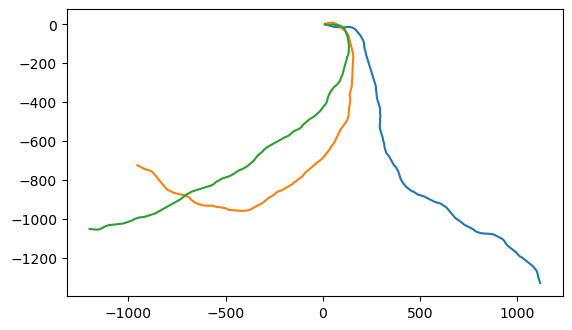

Average Reward:  0.18196626
Epoch 1/32, loss = 21.714207
Epoch 2/32, loss = 8.325525
Epoch 3/32, loss = 13.979848
Epoch 4/32, loss = 6.414841
Epoch 5/32, loss = 3.712383
Epoch 6/32, loss = 10.530069
Epoch 7/32, loss = 3.506724
Epoch 8/32, loss = 2.543410
Epoch 9/32, loss = 1.852852
Epoch 10/32, loss = 1.313449
Epoch 11/32, loss = 2.115331
Epoch 12/32, loss = 0.765408
Epoch 13/32, loss = 0.813901
Epoch 14/32, loss = 0.280666
Epoch 15/32, loss = 0.513000
Epoch 16/32, loss = 0.222503
Epoch 17/32, loss = 4.454416
Epoch 18/32, loss = 0.276554
Epoch 19/32, loss = 0.042758
Epoch 20/32, loss = 3.874076
Epoch 21/32, loss = 0.054530
Epoch 22/32, loss = 0.035789
Epoch 23/32, loss = 0.094743
Epoch 24/32, loss = 0.031621
Epoch 25/32, loss = 0.091154
Epoch 26/32, loss = 0.213828
Epoch 27/32, loss = 2.235656
Epoch 28/32, loss = 0.101104
Epoch 29/32, loss = 0.022268
Epoch 30/32, loss = 2.319649
Epoch 31/32, loss = 0.117925
Epoch 32/32, loss = 0.071308
Saved checkpoint at ./CheckpointsN=3/cycle_30.ckpt

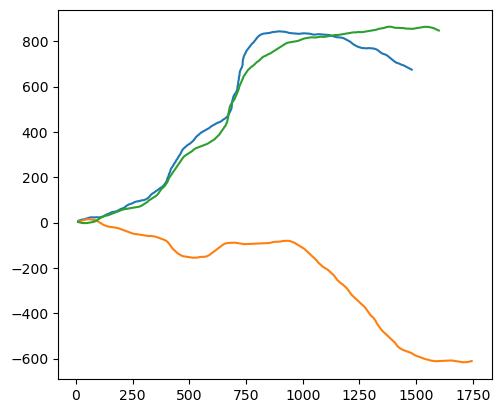

Average Reward:  0.4758053
Epoch 1/32, loss = 48.176037
Epoch 2/32, loss = 22.750935
Epoch 3/32, loss = 35.921215
Epoch 4/32, loss = 30.373875
Epoch 5/32, loss = 20.115671
Epoch 6/32, loss = 14.265849
Epoch 7/32, loss = 11.727519
Epoch 8/32, loss = 30.104752
Epoch 9/32, loss = 5.464225
Epoch 10/32, loss = 13.458313
Epoch 11/32, loss = 17.891371
Epoch 12/32, loss = 6.695579
Epoch 13/32, loss = 9.619175
Epoch 14/32, loss = 13.045210
Epoch 15/32, loss = 8.705401
Epoch 16/32, loss = 3.194784
Epoch 17/32, loss = 16.603697
Epoch 18/32, loss = 5.067904
Epoch 19/32, loss = 12.889513
Epoch 20/32, loss = 18.429173
Epoch 21/32, loss = 3.977577
Epoch 22/32, loss = 6.109119
Epoch 23/32, loss = 25.439135
Epoch 24/32, loss = 39.333561
Epoch 25/32, loss = 2.379058
Epoch 26/32, loss = 1.446908
Epoch 27/32, loss = 4.281705
Epoch 28/32, loss = 17.298433
Epoch 29/32, loss = 17.892761
Epoch 30/32, loss = 2.140814
Epoch 31/32, loss = 9.217702
Epoch 32/32, loss = 15.407899
Saved checkpoint at ./CheckpointsN=

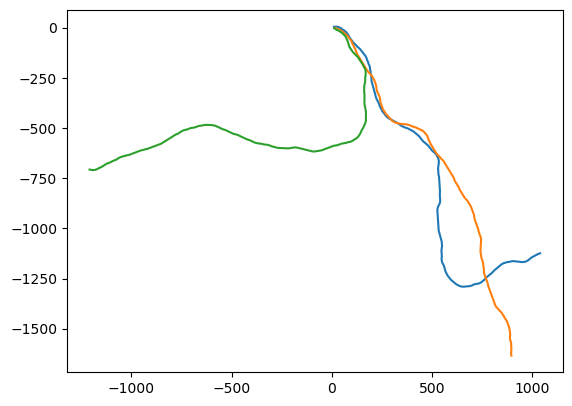

Average Reward:  0.38365597
Epoch 1/32, loss = 99.567764
Epoch 2/32, loss = 48.531902
Epoch 3/32, loss = 15.286043
Epoch 4/32, loss = 11.475866
Epoch 5/32, loss = 8.557829
Epoch 6/32, loss = 16.783094
Epoch 7/32, loss = 9.699470
Epoch 8/32, loss = 4.878268
Epoch 9/32, loss = 9.772946
Epoch 10/32, loss = 13.004408
Epoch 11/32, loss = 13.971063
Epoch 12/32, loss = 2.797453
Epoch 13/32, loss = 4.661883
Epoch 14/32, loss = 7.634067
Epoch 15/32, loss = 11.347396
Epoch 16/32, loss = 3.262126
Epoch 17/32, loss = 3.599291
Epoch 18/32, loss = 0.894928
Epoch 19/32, loss = 12.133214
Epoch 20/32, loss = 4.160082
Epoch 21/32, loss = 4.328760
Epoch 22/32, loss = 9.606187
Epoch 23/32, loss = 0.587637
Epoch 24/32, loss = 0.603447
Epoch 25/32, loss = 1.005488
Epoch 26/32, loss = 7.064773
Epoch 27/32, loss = 6.823826
Epoch 28/32, loss = 2.030899
Epoch 29/32, loss = 3.530901
Epoch 30/32, loss = 1.529582
Epoch 31/32, loss = 4.123993
Epoch 32/32, loss = 1.722464
Saved checkpoint at ./CheckpointsN=3/cycle_3

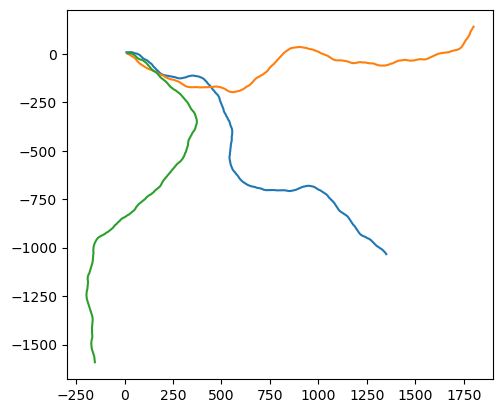

Average Reward:  0.21257935
Epoch 1/32, loss = 39.507454
Epoch 2/32, loss = 7.965667
Epoch 3/32, loss = 15.661145
Epoch 4/32, loss = 29.037416
Epoch 5/32, loss = 0.882079
Epoch 6/32, loss = 25.376482
Epoch 7/32, loss = 11.741001
Epoch 8/32, loss = 0.619172
Epoch 9/32, loss = 0.170606
Epoch 10/32, loss = 0.340870
Epoch 11/32, loss = 1.811856
Epoch 12/32, loss = 0.604615
Epoch 13/32, loss = 4.227798
Epoch 14/32, loss = 9.838380
Epoch 15/32, loss = 23.212955
Epoch 16/32, loss = 9.775440
Epoch 17/32, loss = 13.598355
Epoch 18/32, loss = 6.685284
Epoch 19/32, loss = 0.182464
Epoch 20/32, loss = 0.412202
Epoch 21/32, loss = 5.409999
Epoch 22/32, loss = 9.878590
Epoch 23/32, loss = 0.097992
Epoch 24/32, loss = 9.863741
Epoch 25/32, loss = 9.709615
Epoch 26/32, loss = 0.098913
Epoch 27/32, loss = 0.057094
Epoch 28/32, loss = 3.894334
Epoch 29/32, loss = 0.063496
Epoch 30/32, loss = 9.802875
Epoch 31/32, loss = 0.173366
Epoch 32/32, loss = 5.418940
Saved checkpoint at ./CheckpointsN=3/cycle_33.

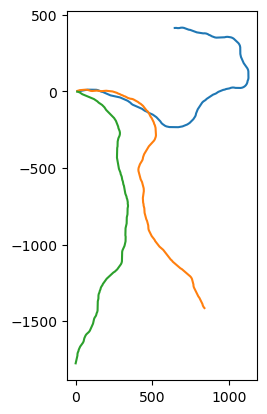

Average Reward:  0.1841797
Epoch 1/32, loss = 17.014492
Epoch 2/32, loss = 18.785429
Epoch 3/32, loss = 30.254467
Epoch 4/32, loss = 15.959033
Epoch 5/32, loss = 1.833017
Epoch 6/32, loss = 5.860188
Epoch 7/32, loss = 0.425117
Epoch 8/32, loss = 2.017224
Epoch 9/32, loss = 0.191928
Epoch 10/32, loss = 6.567100
Epoch 11/32, loss = 2.023242
Epoch 12/32, loss = 0.869757
Epoch 13/32, loss = 8.408826
Epoch 14/32, loss = 8.861987
Epoch 15/32, loss = 0.313658
Epoch 16/32, loss = 17.891735
Epoch 17/32, loss = 5.248135
Epoch 18/32, loss = 16.516459
Epoch 19/32, loss = 2.691301
Epoch 20/32, loss = 0.178911
Epoch 21/32, loss = 0.184213
Epoch 22/32, loss = 0.188974
Epoch 23/32, loss = 8.739799
Epoch 24/32, loss = 16.449062
Epoch 25/32, loss = 8.757347
Epoch 26/32, loss = 0.136788
Epoch 27/32, loss = 1.557689
Epoch 28/32, loss = 17.401628
Epoch 29/32, loss = 16.289671
Epoch 30/32, loss = 0.112831
Epoch 31/32, loss = 0.094477
Epoch 32/32, loss = 21.969149
Saved checkpoint at ./CheckpointsN=3/cycle_3

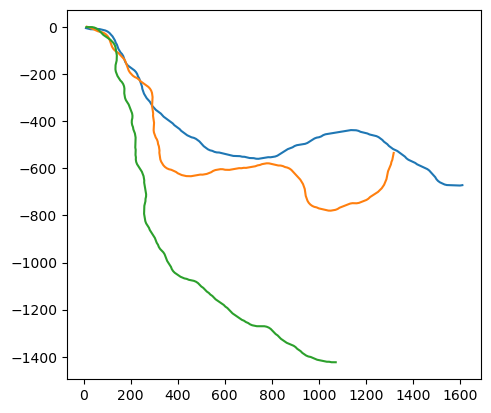

Average Reward:  0.31624058
Epoch 1/32, loss = 48.906853
Epoch 2/32, loss = 47.800041
Epoch 3/32, loss = 13.620700
Epoch 4/32, loss = 39.265423
Epoch 5/32, loss = 6.317218
Epoch 6/32, loss = 15.745087
Epoch 7/32, loss = 11.371647
Epoch 8/32, loss = 0.668223
Epoch 9/32, loss = 4.671347
Epoch 10/32, loss = 1.905762
Epoch 11/32, loss = 0.669972
Epoch 12/32, loss = 2.809405
Epoch 13/32, loss = 1.055547
Epoch 14/32, loss = 0.388237
Epoch 15/32, loss = 1.435850
Epoch 16/32, loss = 0.443927
Epoch 17/32, loss = 1.284798
Epoch 18/32, loss = 14.592229
Epoch 19/32, loss = 0.267660
Epoch 20/32, loss = 0.083377
Epoch 21/32, loss = 0.580842
Epoch 22/32, loss = 9.877724
Epoch 23/32, loss = 0.102839
Epoch 24/32, loss = 16.837786
Epoch 25/32, loss = 26.226751
Epoch 26/32, loss = 4.007944
Epoch 27/32, loss = 0.639443
Epoch 28/32, loss = 0.023506
Epoch 29/32, loss = 0.132775
Epoch 30/32, loss = 17.393099
Epoch 31/32, loss = 0.116229
Epoch 32/32, loss = 13.933149
Saved checkpoint at ./CheckpointsN=3/cycle

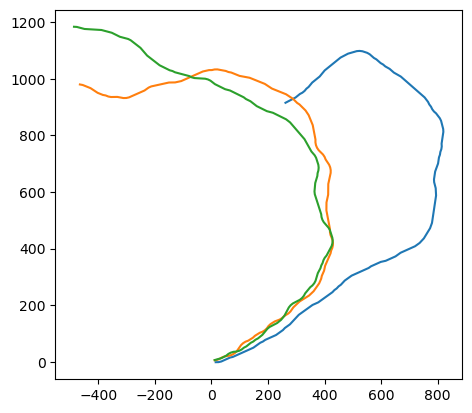

Average Reward:  0.42707342
Epoch 1/32, loss = 94.210297
Epoch 2/32, loss = 52.665070
Epoch 3/32, loss = 61.491234
Epoch 4/32, loss = 43.143795
Epoch 5/32, loss = 22.300276
Epoch 6/32, loss = 44.215607
Epoch 7/32, loss = 58.273956
Epoch 8/32, loss = 11.586765
Epoch 9/32, loss = 6.118985
Epoch 10/32, loss = 12.338121
Epoch 11/32, loss = 47.795681
Epoch 12/32, loss = 18.014904
Epoch 13/32, loss = 3.205692
Epoch 14/32, loss = 4.551677
Epoch 15/32, loss = 3.271499
Epoch 16/32, loss = 2.045116
Epoch 17/32, loss = 1.718077
Epoch 18/32, loss = 16.749302
Epoch 19/32, loss = 24.316847
Epoch 20/32, loss = 4.076993
Epoch 21/32, loss = 0.489870
Epoch 22/32, loss = 1.356216
Epoch 23/32, loss = 8.643463
Epoch 24/32, loss = 11.349346
Epoch 25/32, loss = 0.930147
Epoch 26/32, loss = 26.735598
Epoch 27/32, loss = 9.003942
Epoch 28/32, loss = 23.713314
Epoch 29/32, loss = 0.935230
Epoch 30/32, loss = 0.278657
Epoch 31/32, loss = 0.574329
Epoch 32/32, loss = 11.597527
Saved checkpoint at ./CheckpointsN=3

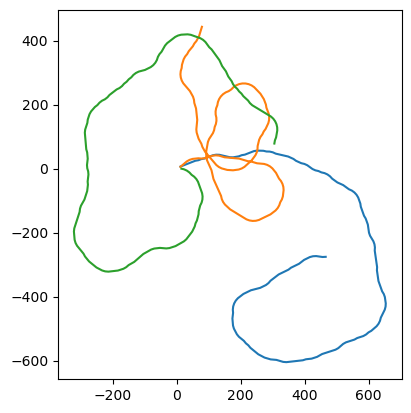

Average Reward:  0.12318938
Epoch 1/32, loss = 14.685965
Epoch 2/32, loss = 8.348541
Epoch 3/32, loss = 0.909918
Epoch 4/32, loss = 0.181181
Epoch 5/32, loss = 1.755994
Epoch 6/32, loss = 0.231864
Epoch 7/32, loss = 5.937070
Epoch 8/32, loss = 0.140006
Epoch 9/32, loss = 0.063903
Epoch 10/32, loss = 0.332126
Epoch 11/32, loss = 0.296107
Epoch 12/32, loss = 0.058016
Epoch 13/32, loss = 0.164569
Epoch 14/32, loss = 5.357685
Epoch 15/32, loss = 0.061869
Epoch 16/32, loss = 0.038026
Epoch 17/32, loss = 0.126132
Epoch 18/32, loss = 0.037607
Epoch 19/32, loss = 0.038081
Epoch 20/32, loss = 0.044316
Epoch 21/32, loss = 0.031340
Epoch 22/32, loss = 0.014640
Epoch 23/32, loss = 0.089954
Epoch 24/32, loss = 5.278967
Epoch 25/32, loss = 0.104170
Epoch 26/32, loss = 0.104133
Epoch 27/32, loss = 0.040834
Epoch 28/32, loss = 0.075219
Epoch 29/32, loss = 0.037585
Epoch 30/32, loss = 0.013598
Epoch 31/32, loss = 0.072204
Epoch 32/32, loss = 0.111600
Saved checkpoint at ./CheckpointsN=3/cycle_37.ckpt



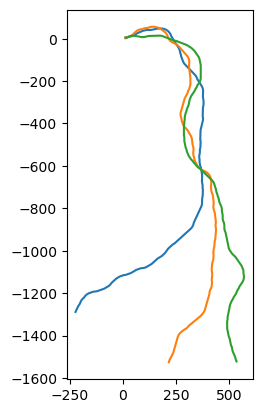

Average Reward:  0.35494706
Epoch 1/32, loss = 132.659103
Epoch 2/32, loss = 95.502304
Epoch 3/32, loss = 81.287201
Epoch 4/32, loss = 83.142235
Epoch 5/32, loss = 25.778456
Epoch 6/32, loss = 69.577553
Epoch 7/32, loss = 86.965271
Epoch 8/32, loss = 20.959995
Epoch 9/32, loss = 31.873497
Epoch 10/32, loss = 58.241814
Epoch 11/32, loss = 27.301321
Epoch 12/32, loss = 40.281170
Epoch 13/32, loss = 20.380354
Epoch 14/32, loss = 47.876991
Epoch 15/32, loss = 38.052719
Epoch 16/32, loss = 28.663031
Epoch 17/32, loss = 10.832684
Epoch 18/32, loss = 5.698229
Epoch 19/32, loss = 18.484476
Epoch 20/32, loss = 29.477970
Epoch 21/32, loss = 3.105072
Epoch 22/32, loss = 5.170740
Epoch 23/32, loss = 31.876026
Epoch 24/32, loss = 41.469898
Epoch 25/32, loss = 34.527214
Epoch 26/32, loss = 12.768102
Epoch 27/32, loss = 7.858606
Epoch 28/32, loss = 20.699486
Epoch 29/32, loss = 38.618298
Epoch 30/32, loss = 35.919819
Epoch 31/32, loss = 40.202347
Epoch 32/32, loss = 36.921944
Saved checkpoint at ./Ch

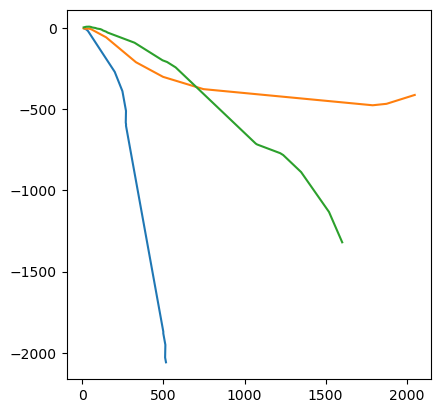

Average Reward:  0.03188582
Epoch 1/32, loss = 33.547703
Epoch 2/32, loss = 17.710354
Epoch 3/32, loss = 8.508941
Epoch 4/32, loss = 5.123765
Epoch 5/32, loss = 5.753911
Epoch 6/32, loss = 5.829097
Epoch 7/32, loss = 6.423530
Epoch 8/32, loss = 0.617961
Epoch 9/32, loss = 10.144426
Epoch 10/32, loss = 0.039274
Epoch 11/32, loss = 0.023312
Epoch 12/32, loss = 0.821503
Epoch 13/32, loss = 2.705087
Epoch 14/32, loss = 1.566486
Epoch 15/32, loss = 11.493750
Epoch 16/32, loss = 0.036772
Epoch 17/32, loss = 0.203047
Epoch 18/32, loss = 3.106597
Epoch 19/32, loss = 0.193595
Epoch 20/32, loss = 0.180345
Epoch 21/32, loss = 0.083805
Epoch 22/32, loss = 0.012107
Epoch 23/32, loss = 0.046663
Epoch 24/32, loss = 0.078195
Epoch 25/32, loss = 0.047265
Epoch 26/32, loss = 0.029573
Epoch 27/32, loss = 0.040478
Epoch 28/32, loss = 0.456786
Epoch 29/32, loss = 0.015907
Epoch 30/32, loss = 0.008417
Epoch 31/32, loss = 0.013253
Epoch 32/32, loss = 0.236710
Saved checkpoint at ./CheckpointsN=3/cycle_39.ckp

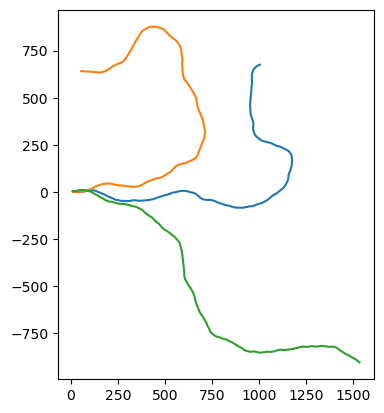

Average Reward:  0.079152994
Epoch 1/32, loss = 46.324547
Epoch 2/32, loss = 36.660110
Epoch 3/32, loss = 21.953468
Epoch 4/32, loss = 7.425132
Epoch 5/32, loss = 1.966673
Epoch 6/32, loss = 5.606010
Epoch 7/32, loss = 1.908828
Epoch 8/32, loss = 0.243097
Epoch 9/32, loss = 0.860709
Epoch 10/32, loss = 0.464656
Epoch 11/32, loss = 11.598640
Epoch 12/32, loss = 0.410900
Epoch 13/32, loss = 1.670850
Epoch 14/32, loss = 3.827254
Epoch 15/32, loss = 0.098107
Epoch 16/32, loss = 2.556180
Epoch 17/32, loss = 1.288893
Epoch 18/32, loss = 1.809464
Epoch 19/32, loss = 1.834863
Epoch 20/32, loss = 0.065361
Epoch 21/32, loss = 0.117327
Epoch 22/32, loss = 0.069404
Epoch 23/32, loss = 0.086311
Epoch 24/32, loss = 7.103522
Epoch 25/32, loss = 1.277504
Epoch 26/32, loss = 0.041211
Epoch 27/32, loss = 0.090723
Epoch 28/32, loss = 0.038757
Epoch 29/32, loss = 1.877211
Epoch 30/32, loss = 0.055718
Epoch 31/32, loss = 0.051867
Epoch 32/32, loss = 3.173197
Saved checkpoint at ./CheckpointsN=3/cycle_40.ck

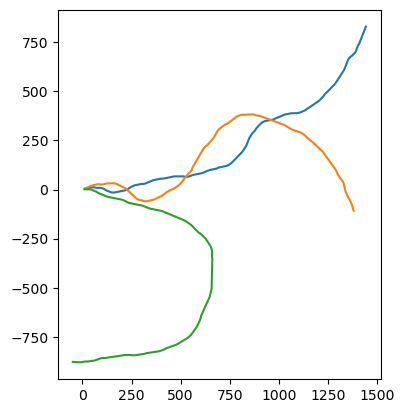

Average Reward:  0.052982688
Epoch 1/32, loss = 16.656162
Epoch 2/32, loss = 21.025461
Epoch 3/32, loss = 43.981041
Epoch 4/32, loss = 8.036207
Epoch 5/32, loss = 31.882147
Epoch 6/32, loss = 26.730785
Epoch 7/32, loss = 1.592566
Epoch 8/32, loss = 21.629524
Epoch 9/32, loss = 9.064489
Epoch 10/32, loss = 1.119043
Epoch 11/32, loss = 2.046395
Epoch 12/32, loss = 1.428421
Epoch 13/32, loss = 0.640314
Epoch 14/32, loss = 12.774980
Epoch 15/32, loss = 9.049289
Epoch 16/32, loss = 1.133203
Epoch 17/32, loss = 10.105347
Epoch 18/32, loss = 3.429712
Epoch 19/32, loss = 19.379875
Epoch 20/32, loss = 1.831922
Epoch 21/32, loss = 0.193156
Epoch 22/32, loss = 11.165542
Epoch 23/32, loss = 18.650499
Epoch 24/32, loss = 0.919173
Epoch 25/32, loss = 0.501092
Epoch 26/32, loss = 0.960258
Epoch 27/32, loss = 0.366213
Epoch 28/32, loss = 0.290862
Epoch 29/32, loss = 0.896208
Epoch 30/32, loss = 19.886805
Epoch 31/32, loss = 12.477875
Epoch 32/32, loss = 51.650387
Saved checkpoint at ./CheckpointsN=3/c

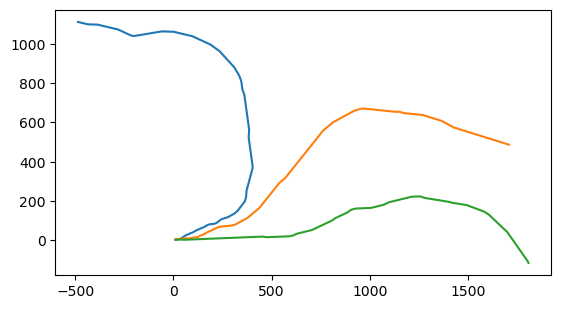

Average Reward:  0.039004505
Epoch 1/32, loss = 61.840820
Epoch 2/32, loss = 30.005566
Epoch 3/32, loss = 6.942472
Epoch 4/32, loss = 17.373522
Epoch 5/32, loss = 11.554493
Epoch 6/32, loss = 1.199173
Epoch 7/32, loss = 13.878188
Epoch 8/32, loss = 5.001427
Epoch 9/32, loss = 2.555000
Epoch 10/32, loss = 0.267675
Epoch 11/32, loss = 16.875360
Epoch 12/32, loss = 6.956394
Epoch 13/32, loss = 7.202576
Epoch 14/32, loss = 13.436626
Epoch 15/32, loss = 5.096516
Epoch 16/32, loss = 0.024716
Epoch 17/32, loss = 0.197766
Epoch 18/32, loss = 12.675261
Epoch 19/32, loss = 5.194856
Epoch 20/32, loss = 0.188350
Epoch 21/32, loss = 16.738501
Epoch 22/32, loss = 0.013678
Epoch 23/32, loss = 0.149773
Epoch 24/32, loss = 4.836730
Epoch 25/32, loss = 0.023257
Epoch 26/32, loss = 4.580723
Epoch 27/32, loss = 4.667104
Epoch 28/32, loss = 0.010622
Epoch 29/32, loss = 14.327856
Epoch 30/32, loss = 15.063940
Epoch 31/32, loss = 4.832120
Epoch 32/32, loss = 0.002315
Saved checkpoint at ./CheckpointsN=3/cycl

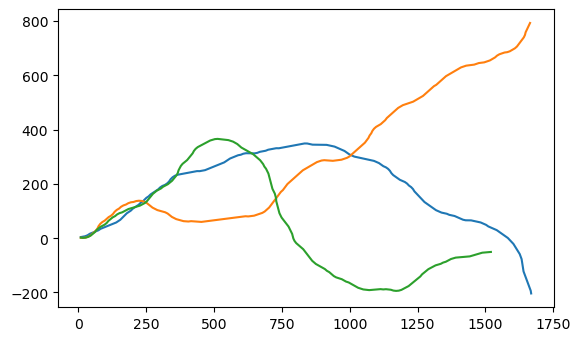

Average Reward:  0.060481083
Epoch 1/32, loss = 109.190453
Epoch 2/32, loss = 72.396133
Epoch 3/32, loss = 11.799900
Epoch 4/32, loss = 8.564141
Epoch 5/32, loss = 4.632405
Epoch 6/32, loss = 16.986101
Epoch 7/32, loss = 1.460495
Epoch 8/32, loss = 35.725231
Epoch 9/32, loss = 2.342609
Epoch 10/32, loss = 1.428519
Epoch 11/32, loss = 24.635178
Epoch 12/32, loss = 2.202572
Epoch 13/32, loss = 20.401213
Epoch 14/32, loss = 20.187918
Epoch 15/32, loss = 1.594064
Epoch 16/32, loss = 8.162819
Epoch 17/32, loss = 37.936382
Epoch 18/32, loss = 61.866329
Epoch 19/32, loss = 19.558548
Epoch 20/32, loss = 0.472558
Epoch 21/32, loss = 3.008700
Epoch 22/32, loss = 0.878587
Epoch 23/32, loss = 1.051597
Epoch 24/32, loss = 52.131584
Epoch 25/32, loss = 5.919846
Epoch 26/32, loss = 66.793152
Epoch 27/32, loss = 7.954355
Epoch 28/32, loss = 52.364563
Epoch 29/32, loss = 1.424531
Epoch 30/32, loss = 24.049051
Epoch 31/32, loss = 0.492387
Epoch 32/32, loss = 66.049927
Saved checkpoint at ./CheckpointsN=

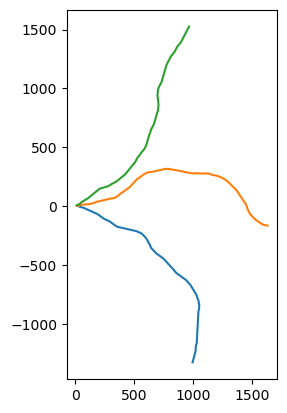

Average Reward:  0.0024034672
Epoch 1/32, loss = 15.475688
Epoch 2/32, loss = 9.893532
Epoch 3/32, loss = 1.055123
Epoch 4/32, loss = 7.914302
Epoch 5/32, loss = 1.051093
Epoch 6/32, loss = 0.633132
Epoch 7/32, loss = 0.075748
Epoch 8/32, loss = 0.095007
Epoch 9/32, loss = 0.035680
Epoch 10/32, loss = 0.016189
Epoch 11/32, loss = 0.032446
Epoch 12/32, loss = 0.140594
Epoch 13/32, loss = 0.460722
Epoch 14/32, loss = 0.005305
Epoch 15/32, loss = 0.180436
Epoch 16/32, loss = 0.001831
Epoch 17/32, loss = 0.004820
Epoch 18/32, loss = 0.008469
Epoch 19/32, loss = 0.001600
Epoch 20/32, loss = 0.001414
Epoch 21/32, loss = 0.003623
Epoch 22/32, loss = 0.000091
Epoch 23/32, loss = 0.000011
Epoch 24/32, loss = 0.000123
Epoch 25/32, loss = 0.000041
Epoch 26/32, loss = 0.000004
Epoch 27/32, loss = 0.000003
Epoch 28/32, loss = 0.000399
Epoch 29/32, loss = 0.000004
Epoch 30/32, loss = 0.000002
Epoch 31/32, loss = 0.000029
Epoch 32/32, loss = 0.000000
Saved checkpoint at ./CheckpointsN=3/cycle_44.ckpt

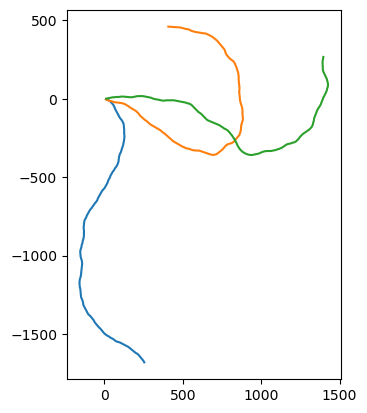

Average Reward:  0.0071171857
Epoch 1/32, loss = 40.995743
Epoch 2/32, loss = 45.779343
Epoch 3/32, loss = 54.511524
Epoch 4/32, loss = 16.815147
Epoch 5/32, loss = 1.385426
Epoch 6/32, loss = 18.614250
Epoch 7/32, loss = 0.672915
Epoch 8/32, loss = 1.160387
Epoch 9/32, loss = 1.234283
Epoch 10/32, loss = 69.450188
Epoch 11/32, loss = 0.750520
Epoch 12/32, loss = 15.284263
Epoch 13/32, loss = 162.691238
Epoch 14/32, loss = 0.474133
Epoch 15/32, loss = 196.347870
Epoch 16/32, loss = 33.049305
Epoch 17/32, loss = 0.749207
Epoch 18/32, loss = 0.561172
Epoch 19/32, loss = 0.458846
Epoch 20/32, loss = 0.268327
Epoch 21/32, loss = 0.451649
Epoch 22/32, loss = 0.338509
Epoch 23/32, loss = 0.331459
Epoch 24/32, loss = 17.988174
Epoch 25/32, loss = 36.346718
Epoch 26/32, loss = 0.350631
Epoch 27/32, loss = 0.249909
Epoch 28/32, loss = 17.933039
Epoch 29/32, loss = 71.999397
Epoch 30/32, loss = 26.656296
Epoch 31/32, loss = 0.167579
Epoch 32/32, loss = 198.439499
Saved checkpoint at ./Checkpoint

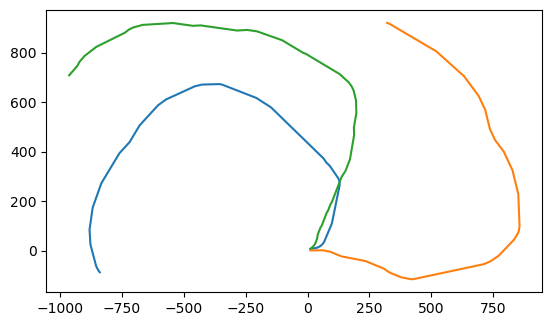

Average Reward:  0.011566399
Epoch 1/32, loss = 64.310799
Epoch 2/32, loss = 17.868677
Epoch 3/32, loss = 15.048878
Epoch 4/32, loss = 12.253165
Epoch 5/32, loss = 37.146893
Epoch 6/32, loss = 5.495852
Epoch 7/32, loss = 5.817956
Epoch 8/32, loss = 1.664473
Epoch 9/32, loss = 14.561208
Epoch 10/32, loss = 7.845141
Epoch 11/32, loss = 77.986588
Epoch 12/32, loss = 2.547008
Epoch 13/32, loss = 77.131729
Epoch 14/32, loss = 0.758333
Epoch 15/32, loss = 0.276361
Epoch 16/32, loss = 76.975983
Epoch 17/32, loss = 1.210679
Epoch 18/32, loss = 1.063530
Epoch 19/32, loss = 76.832199
Epoch 20/32, loss = 0.306722
Epoch 21/32, loss = 0.325002
Epoch 22/32, loss = 0.386194
Epoch 23/32, loss = 0.284236
Epoch 24/32, loss = 33.215679
Epoch 25/32, loss = 1.246871
Epoch 26/32, loss = 0.175814
Epoch 27/32, loss = 0.234624
Epoch 28/32, loss = 0.284455
Epoch 29/32, loss = 0.359336
Epoch 30/32, loss = 0.231095
Epoch 31/32, loss = 0.284221
Epoch 32/32, loss = 0.811127
Saved checkpoint at ./CheckpointsN=3/cycl

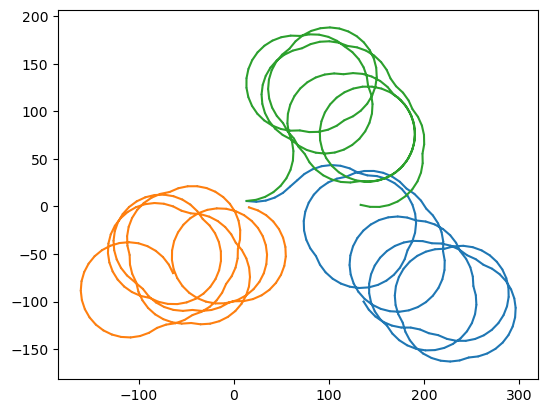

Average Reward:  0.0012036299
Epoch 1/32, loss = 33.217270
Epoch 2/32, loss = 7.489380
Epoch 3/32, loss = 16.285709
Epoch 4/32, loss = 5.773225
Epoch 5/32, loss = 0.255484
Epoch 6/32, loss = 1.359142
Epoch 7/32, loss = 0.092074
Epoch 8/32, loss = 0.001767
Epoch 9/32, loss = 0.011450
Epoch 10/32, loss = 0.003118
Epoch 11/32, loss = 0.075643
Epoch 12/32, loss = 0.001365
Epoch 13/32, loss = 0.019879
Epoch 14/32, loss = 0.000688
Epoch 15/32, loss = 0.005960
Epoch 16/32, loss = 0.021950
Epoch 17/32, loss = 0.000069
Epoch 18/32, loss = 0.000217
Epoch 19/32, loss = 0.000019
Epoch 20/32, loss = 0.000291
Epoch 21/32, loss = 0.000329
Epoch 22/32, loss = 0.044398
Epoch 23/32, loss = 0.000073
Epoch 24/32, loss = 0.000017
Epoch 25/32, loss = 0.000064
Epoch 26/32, loss = 0.029036
Epoch 27/32, loss = 0.000086
Epoch 28/32, loss = 0.000054
Epoch 29/32, loss = 0.036253
Epoch 30/32, loss = 0.000034
Epoch 31/32, loss = 0.000004
Epoch 32/32, loss = 0.007920
Saved checkpoint at ./CheckpointsN=3/cycle_47.ckp

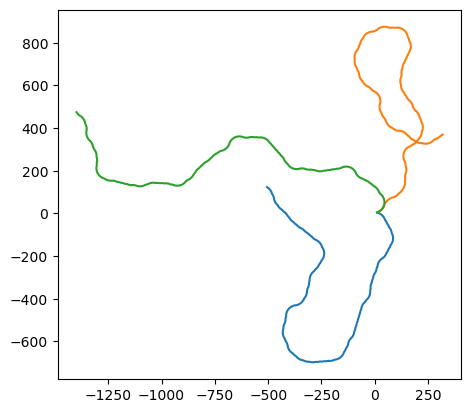

Average Reward:  0.00093722524
Epoch 1/32, loss = 2.984569
Epoch 2/32, loss = 2.133934
Epoch 3/32, loss = 0.387660
Epoch 4/32, loss = 0.140324
Epoch 5/32, loss = 0.014959
Epoch 6/32, loss = 0.028607
Epoch 7/32, loss = 0.089728
Epoch 8/32, loss = 0.014662
Epoch 9/32, loss = 0.025089
Epoch 10/32, loss = 0.008145
Epoch 11/32, loss = 0.010459
Epoch 12/32, loss = 0.003897
Epoch 13/32, loss = 0.004775
Epoch 14/32, loss = 0.020443
Epoch 15/32, loss = 0.001368
Epoch 16/32, loss = 0.001951
Epoch 17/32, loss = 0.002268
Epoch 18/32, loss = 0.001521
Epoch 19/32, loss = 0.017059
Epoch 20/32, loss = 0.000204
Epoch 21/32, loss = 0.000031
Epoch 22/32, loss = 0.000925
Epoch 23/32, loss = 0.000027
Epoch 24/32, loss = 0.015744
Epoch 25/32, loss = 0.000003
Epoch 26/32, loss = 0.000016
Epoch 27/32, loss = 0.000007
Epoch 28/32, loss = 0.000894
Epoch 29/32, loss = 0.000010
Epoch 30/32, loss = 0.013332
Epoch 31/32, loss = 0.000017
Epoch 32/32, loss = 0.012665
Saved checkpoint at ./CheckpointsN=3/cycle_48.ckpt

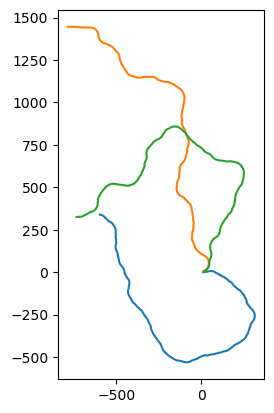

Average Reward:  0.0
Epoch 1/32, loss = 11.573583
Epoch 2/32, loss = 4.070140
Epoch 3/32, loss = 7.826728
Epoch 4/32, loss = 3.348614
Epoch 5/32, loss = 0.339389
Epoch 6/32, loss = 1.199038
Epoch 7/32, loss = 0.491154
Epoch 8/32, loss = 0.033623
Epoch 9/32, loss = 0.000348
Epoch 10/32, loss = 0.011931
Epoch 11/32, loss = 0.005380
Epoch 12/32, loss = 0.007420
Epoch 13/32, loss = 0.007148
Epoch 14/32, loss = 0.011180
Epoch 15/32, loss = 0.001899
Epoch 16/32, loss = 0.000481
Epoch 17/32, loss = 0.000211
Epoch 18/32, loss = 0.000088
Epoch 19/32, loss = 0.000109
Epoch 20/32, loss = 0.000010
Epoch 21/32, loss = 0.000041
Epoch 22/32, loss = 0.000013
Epoch 23/32, loss = 0.000002
Epoch 24/32, loss = 0.000003
Epoch 25/32, loss = 0.000001
Epoch 26/32, loss = 0.000000
Epoch 27/32, loss = 0.000000
Epoch 28/32, loss = 0.000000
Epoch 29/32, loss = 0.000000
Epoch 30/32, loss = 0.000000
Epoch 31/32, loss = 0.000000
Epoch 32/32, loss = 0.000000
Saved checkpoint at ./CheckpointsN=3/cycle_49.ckpt

=== Tra

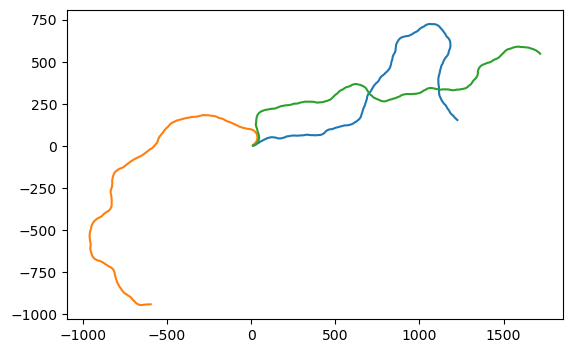

Average Reward:  0.0
Epoch 1/32, loss = 12.128414
Epoch 2/32, loss = 10.093463
Epoch 3/32, loss = 2.228399
Epoch 4/32, loss = 2.776671
Epoch 5/32, loss = 1.684970
Epoch 6/32, loss = 0.098964
Epoch 7/32, loss = 0.608722
Epoch 8/32, loss = 0.041577
Epoch 9/32, loss = 0.389078
Epoch 10/32, loss = 0.021374
Epoch 11/32, loss = 0.037870
Epoch 12/32, loss = 0.604839
Epoch 13/32, loss = 0.544515
Epoch 14/32, loss = 0.012820
Epoch 15/32, loss = 0.010197
Epoch 16/32, loss = 0.001738
Epoch 17/32, loss = 0.002640
Epoch 18/32, loss = 0.000390
Epoch 19/32, loss = 0.119930
Epoch 20/32, loss = 0.000474
Epoch 21/32, loss = 0.087818
Epoch 22/32, loss = 0.006905
Epoch 23/32, loss = 0.011299
Epoch 24/32, loss = 0.004026
Epoch 25/32, loss = 0.000705
Epoch 26/32, loss = 0.000045
Epoch 27/32, loss = 0.000109
Epoch 28/32, loss = 0.017712
Epoch 29/32, loss = 0.000020
Epoch 30/32, loss = 0.000760
Epoch 31/32, loss = 0.000162
Epoch 32/32, loss = 0.009916
Saved checkpoint at ./CheckpointsN=3/cycle_50.ckpt

=== Tr

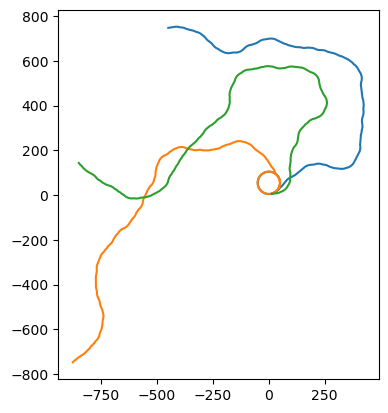

Average Reward:  0.0
Epoch 1/32, loss = 43.658703
Epoch 2/32, loss = 106.933868
Epoch 3/32, loss = 11.344037
Epoch 4/32, loss = 21.100199
Epoch 5/32, loss = 21.918432
Epoch 6/32, loss = 31.428051
Epoch 7/32, loss = 88.983612
Epoch 8/32, loss = 15.274435
Epoch 9/32, loss = 13.541540
Epoch 10/32, loss = 68.766464
Epoch 11/32, loss = 9.633783
Epoch 12/32, loss = 2.069834
Epoch 13/32, loss = 32.308552
Epoch 14/32, loss = 42.595604
Epoch 15/32, loss = 35.075722
Epoch 16/32, loss = 30.821144
Epoch 17/32, loss = 4.072368
Epoch 18/32, loss = 9.204638
Epoch 19/32, loss = 46.269783
Epoch 20/32, loss = 21.574682
Epoch 21/32, loss = 18.586281
Epoch 22/32, loss = 26.681602
Epoch 23/32, loss = 2.393125
Epoch 24/32, loss = 1.891616
Epoch 25/32, loss = 101.123421
Epoch 26/32, loss = 28.447802
Epoch 27/32, loss = 8.631299
Epoch 28/32, loss = 10.879771
Epoch 29/32, loss = 18.951715
Epoch 30/32, loss = 74.319527
Epoch 31/32, loss = 8.983011
Epoch 32/32, loss = 30.409815
Saved checkpoint at ./CheckpointsN

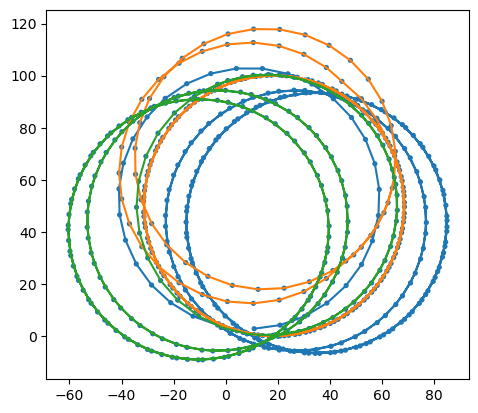

Average Reward:  0.00093722524
Epoch 1/32, loss = 1340.385010
Epoch 2/32, loss = 1013.248779
Epoch 3/32, loss = 274.621887
Epoch 4/32, loss = 501.540375
Epoch 5/32, loss = 474.760101
Epoch 6/32, loss = 417.532410
Epoch 7/32, loss = 443.757385
Epoch 8/32, loss = 594.033142
Epoch 9/32, loss = 499.176697
Epoch 10/32, loss = 350.150269
Epoch 11/32, loss = 685.285156
Epoch 12/32, loss = 192.096130
Epoch 13/32, loss = 485.098328
Epoch 14/32, loss = 518.623169
Epoch 15/32, loss = 245.709579
Epoch 16/32, loss = 508.689697
Epoch 17/32, loss = 199.806900
Epoch 18/32, loss = 214.193054
Epoch 19/32, loss = 55.454514
Epoch 20/32, loss = 268.856873
Epoch 21/32, loss = 613.998230
Epoch 22/32, loss = 192.507904
Epoch 23/32, loss = 306.324829
Epoch 24/32, loss = 255.220535
Epoch 25/32, loss = 215.026825
Epoch 26/32, loss = 233.552567
Epoch 27/32, loss = 552.782166
Epoch 28/32, loss = 382.908112
Epoch 29/32, loss = 305.277893
Epoch 30/32, loss = 583.884338
Epoch 31/32, loss = 485.015289
Epoch 32/32, los

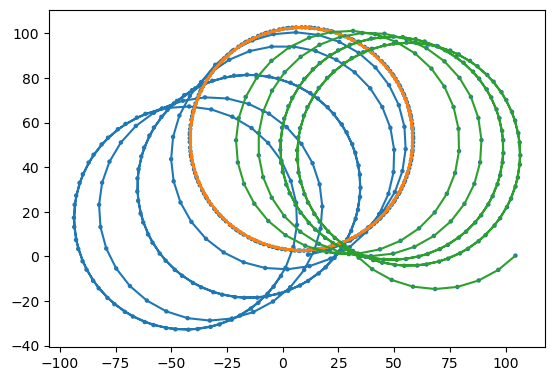

Average Reward:  0.0
Epoch 1/32, loss = 1745.747681
Epoch 2/32, loss = 1046.821777
Epoch 3/32, loss = 1686.834351
Epoch 4/32, loss = 577.863403
Epoch 5/32, loss = 893.571533
Epoch 6/32, loss = 390.489288
Epoch 7/32, loss = 943.597229
Epoch 8/32, loss = 221.854279
Epoch 9/32, loss = 894.987183
Epoch 10/32, loss = 415.644104
Epoch 11/32, loss = 753.909729
Epoch 12/32, loss = 683.862183
Epoch 13/32, loss = 904.513123
Epoch 14/32, loss = 846.496460
Epoch 15/32, loss = 742.211792
Epoch 16/32, loss = 301.642029
Epoch 17/32, loss = 240.850235
Epoch 18/32, loss = 858.230713
Epoch 19/32, loss = 367.739136
Epoch 20/32, loss = 587.194519
Epoch 21/32, loss = 207.144043
Epoch 22/32, loss = 1226.443115
Epoch 23/32, loss = 413.691650
Epoch 24/32, loss = 392.580322
Epoch 25/32, loss = 575.350464
Epoch 26/32, loss = 418.233093
Epoch 27/32, loss = 786.311462
Epoch 28/32, loss = 346.077637
Epoch 29/32, loss = 920.863770
Epoch 30/32, loss = 767.992432
Epoch 31/32, loss = 313.959656
Epoch 32/32, loss = 436

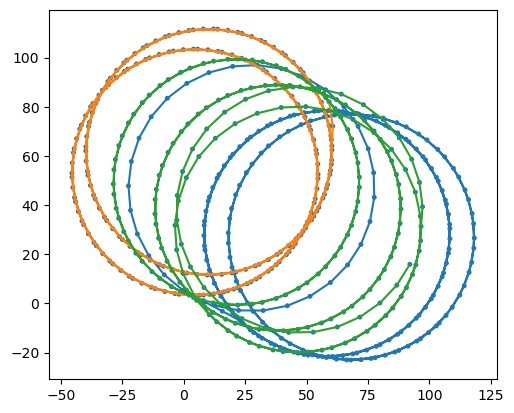

Average Reward:  0.0
Epoch 1/32, loss = 1222.726685
Epoch 2/32, loss = 1421.164062
Epoch 3/32, loss = 1166.506104
Epoch 4/32, loss = 439.934509
Epoch 5/32, loss = 1329.781616
Epoch 6/32, loss = 1272.975952
Epoch 7/32, loss = 800.708496
Epoch 8/32, loss = 913.655884
Epoch 9/32, loss = 751.267517
Epoch 10/32, loss = 1090.802490
Epoch 11/32, loss = 279.667297
Epoch 12/32, loss = 778.729919
Epoch 13/32, loss = 642.611938
Epoch 14/32, loss = 1203.910034
Epoch 15/32, loss = 1178.041626
Epoch 16/32, loss = 294.499268
Epoch 17/32, loss = 422.545563
Epoch 18/32, loss = 763.845215
Epoch 19/32, loss = 329.909668
Epoch 20/32, loss = 380.775024
Epoch 21/32, loss = 520.523743
Epoch 22/32, loss = 1134.827759
Epoch 23/32, loss = 921.561890
Epoch 24/32, loss = 280.676392
Epoch 25/32, loss = 668.489380
Epoch 26/32, loss = 468.092346
Epoch 27/32, loss = 453.941833
Epoch 28/32, loss = 649.855591
Epoch 29/32, loss = 730.566223
Epoch 30/32, loss = 313.286377
Epoch 31/32, loss = 883.109619
Epoch 32/32, loss 

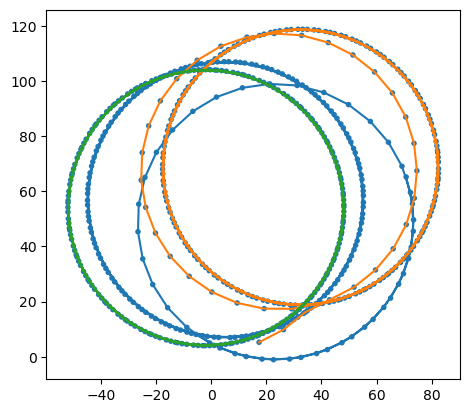

Average Reward:  0.0
Epoch 1/32, loss = 1101.859985
Epoch 2/32, loss = 769.251587
Epoch 3/32, loss = 466.411804
Epoch 4/32, loss = 884.965454
Epoch 5/32, loss = 494.600220
Epoch 6/32, loss = 436.863220
Epoch 7/32, loss = 705.671875
Epoch 8/32, loss = 208.011673
Epoch 9/32, loss = 304.363403
Epoch 10/32, loss = 477.586090
Epoch 11/32, loss = 121.938728
Epoch 12/32, loss = 356.339996
Epoch 13/32, loss = 474.780396
Epoch 14/32, loss = 398.677429
Epoch 15/32, loss = 182.455170
Epoch 16/32, loss = 870.146057
Epoch 17/32, loss = 149.996796
Epoch 18/32, loss = 100.285385
Epoch 19/32, loss = 271.051819
Epoch 20/32, loss = 418.042023
Epoch 21/32, loss = 54.846565
Epoch 22/32, loss = 240.369080
Epoch 23/32, loss = 309.230865
Epoch 24/32, loss = 134.471649
Epoch 25/32, loss = 89.433609
Epoch 26/32, loss = 162.591553
Epoch 27/32, loss = 217.147552
Epoch 28/32, loss = 288.069031
Epoch 29/32, loss = 340.302368
Epoch 30/32, loss = 360.071289
Epoch 31/32, loss = 53.611958
Epoch 32/32, loss = 147.32560

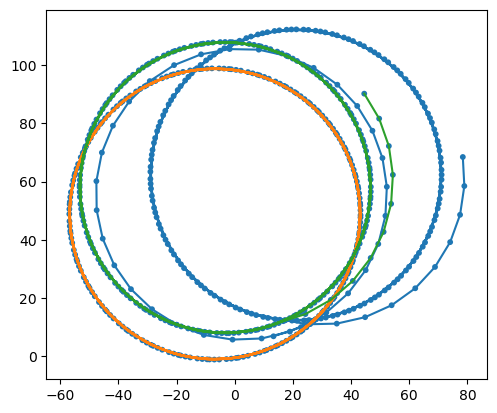

Average Reward:  0.0
Epoch 1/32, loss = 1816.505371
Epoch 2/32, loss = 779.499878
Epoch 3/32, loss = 635.834534
Epoch 4/32, loss = 370.736084
Epoch 5/32, loss = 363.160553
Epoch 6/32, loss = 243.461777
Epoch 7/32, loss = 469.810059
Epoch 8/32, loss = 309.664276
Epoch 9/32, loss = 181.636505
Epoch 10/32, loss = 239.322296
Epoch 11/32, loss = 403.726379
Epoch 12/32, loss = 126.073074
Epoch 13/32, loss = 153.401550
Epoch 14/32, loss = 100.162216
Epoch 15/32, loss = 255.843704
Epoch 16/32, loss = 248.651779
Epoch 17/32, loss = 119.104340
Epoch 18/32, loss = 204.712494
Epoch 19/32, loss = 204.945786
Epoch 20/32, loss = 164.596771
Epoch 21/32, loss = 268.119019
Epoch 22/32, loss = 141.753799
Epoch 23/32, loss = 232.646301
Epoch 24/32, loss = 151.086395
Epoch 25/32, loss = 362.288452
Epoch 26/32, loss = 169.421707
Epoch 27/32, loss = 78.040131
Epoch 28/32, loss = 134.104904
Epoch 29/32, loss = 177.866409
Epoch 30/32, loss = 363.489441
Epoch 31/32, loss = 330.398590
Epoch 32/32, loss = 116.322

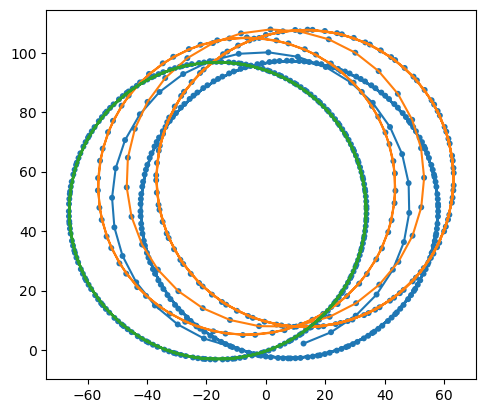

Average Reward:  0.0
Epoch 1/32, loss = 1946.460938
Epoch 2/32, loss = 892.722778
Epoch 3/32, loss = 487.750671
Epoch 4/32, loss = 463.270782
Epoch 5/32, loss = 487.223694
Epoch 6/32, loss = 483.234833
Epoch 7/32, loss = 375.254761
Epoch 8/32, loss = 457.891663
Epoch 9/32, loss = 360.873657
Epoch 10/32, loss = 412.699432
Epoch 11/32, loss = 326.866028
Epoch 12/32, loss = 180.920532
Epoch 13/32, loss = 208.706253
Epoch 14/32, loss = 280.896179
Epoch 15/32, loss = 219.336609
Epoch 16/32, loss = 406.494263
Epoch 17/32, loss = 324.533661
Epoch 18/32, loss = 363.541504
Epoch 19/32, loss = 221.234451
Epoch 20/32, loss = 276.193726
Epoch 21/32, loss = 265.394989
Epoch 22/32, loss = 175.854813
Epoch 23/32, loss = 244.098389
Epoch 24/32, loss = 302.227478
Epoch 25/32, loss = 285.511383
Epoch 26/32, loss = 196.327972
Epoch 27/32, loss = 195.578369
Epoch 28/32, loss = 458.435791
Epoch 29/32, loss = 28.417826
Epoch 30/32, loss = 397.665588
Epoch 31/32, loss = 170.208862
Epoch 32/32, loss = 186.167

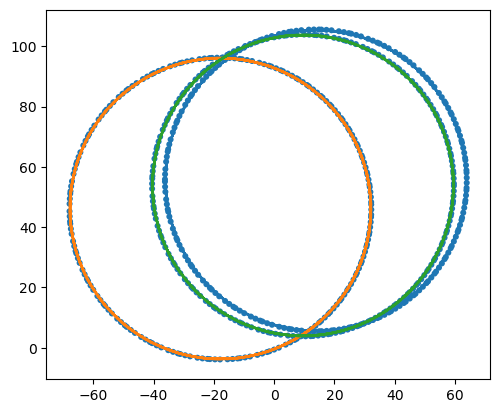

Average Reward:  0.0
Epoch 1/32, loss = 919.746460
Epoch 2/32, loss = 272.409729
Epoch 3/32, loss = 482.427704
Epoch 4/32, loss = 252.618469
Epoch 5/32, loss = 412.787109
Epoch 6/32, loss = 517.380127
Epoch 7/32, loss = 228.389206
Epoch 8/32, loss = 306.264252
Epoch 9/32, loss = 431.002319
Epoch 10/32, loss = 366.423828
Epoch 11/32, loss = 267.787750
Epoch 12/32, loss = 258.332733
Epoch 13/32, loss = 331.255737
Epoch 14/32, loss = 307.563232
Epoch 15/32, loss = 314.677094
Epoch 16/32, loss = 401.815979
Epoch 17/32, loss = 358.697662
Epoch 18/32, loss = 84.579353
Epoch 19/32, loss = 43.883820
Epoch 20/32, loss = 285.403778
Epoch 21/32, loss = 34.271088
Epoch 22/32, loss = 41.332474
Epoch 23/32, loss = 152.440109
Epoch 24/32, loss = 176.594269
Epoch 25/32, loss = 164.021149
Epoch 26/32, loss = 287.402802
Epoch 27/32, loss = 87.735184
Epoch 28/32, loss = 338.010193
Epoch 29/32, loss = 109.737198
Epoch 30/32, loss = 178.964661
Epoch 31/32, loss = 262.039368
Epoch 32/32, loss = 84.092537
Sa

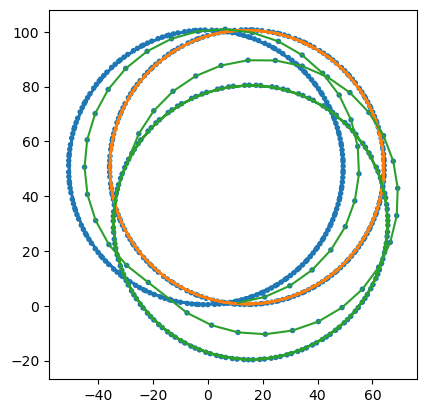

Average Reward:  0.0
Epoch 1/32, loss = 825.208862
Epoch 2/32, loss = 508.555969
Epoch 3/32, loss = 373.784393
Epoch 4/32, loss = 370.828796
Epoch 5/32, loss = 292.233612
Epoch 6/32, loss = 232.974060
Epoch 7/32, loss = 294.962402
Epoch 8/32, loss = 158.541687
Epoch 9/32, loss = 133.010742
Epoch 10/32, loss = 356.619202
Epoch 11/32, loss = 188.228638
Epoch 12/32, loss = 126.634781
Epoch 13/32, loss = 142.696716
Epoch 14/32, loss = 195.672882
Epoch 15/32, loss = 165.079453
Epoch 16/32, loss = 192.106110
Epoch 17/32, loss = 144.121155
Epoch 18/32, loss = 177.674744
Epoch 19/32, loss = 145.122803
Epoch 20/32, loss = 173.255341
Epoch 21/32, loss = 204.392944
Epoch 22/32, loss = 110.227951
Epoch 23/32, loss = 152.498291
Epoch 24/32, loss = 398.214600
Epoch 25/32, loss = 66.895874
Epoch 26/32, loss = 115.175247
Epoch 27/32, loss = 195.064545
Epoch 28/32, loss = 220.495270
Epoch 29/32, loss = 85.970428
Epoch 30/32, loss = 334.097900
Epoch 31/32, loss = 157.471542
Epoch 32/32, loss = 96.020508

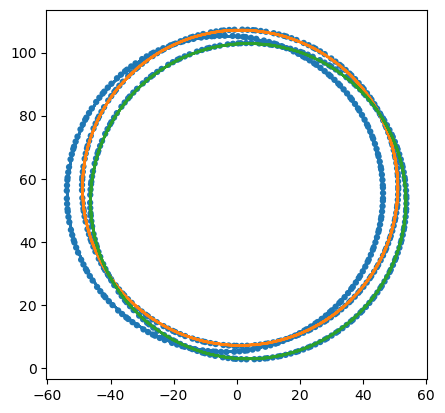

Average Reward:  0.0
Epoch 1/32, loss = 704.511597
Epoch 2/32, loss = 268.746185
Epoch 3/32, loss = 238.108337
Epoch 4/32, loss = 254.965302
Epoch 5/32, loss = 134.658478
Epoch 6/32, loss = 138.782837
Epoch 7/32, loss = 74.802582
Epoch 8/32, loss = 142.540909
Epoch 9/32, loss = 256.440552
Epoch 10/32, loss = 115.462250
Epoch 11/32, loss = 155.876801
Epoch 12/32, loss = 232.639130
Epoch 13/32, loss = 47.223114
Epoch 14/32, loss = 204.400818
Epoch 15/32, loss = 152.303619
Epoch 16/32, loss = 137.029907
Epoch 17/32, loss = 147.899780
Epoch 18/32, loss = 141.495850
Epoch 19/32, loss = 179.414764
Epoch 20/32, loss = 32.987213
Epoch 21/32, loss = 36.359852
Epoch 22/32, loss = 171.285156
Epoch 23/32, loss = 82.191681
Epoch 24/32, loss = 132.698639
Epoch 25/32, loss = 106.962006
Epoch 26/32, loss = 32.323742
Epoch 27/32, loss = 54.114723
Epoch 28/32, loss = 40.327843
Epoch 29/32, loss = 108.473969
Epoch 30/32, loss = 75.823898
Epoch 31/32, loss = 145.931610
Epoch 32/32, loss = 81.177734
Saved 

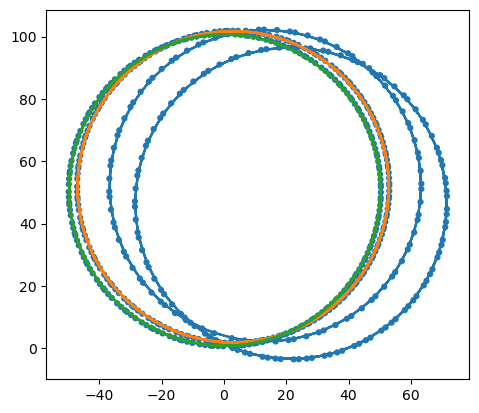

Average Reward:  0.0
Epoch 1/32, loss = 637.685547
Epoch 2/32, loss = 347.291565
Epoch 3/32, loss = 339.219055
Epoch 4/32, loss = 282.094940
Epoch 5/32, loss = 314.189301
Epoch 6/32, loss = 268.135956
Epoch 7/32, loss = 235.981796
Epoch 8/32, loss = 188.562531
Epoch 9/32, loss = 243.677490
Epoch 10/32, loss = 226.631516
Epoch 11/32, loss = 268.074585
Epoch 12/32, loss = 94.567543
Epoch 13/32, loss = 260.896057
Epoch 14/32, loss = 143.686859
Epoch 15/32, loss = 269.223083
Epoch 16/32, loss = 103.517738
Epoch 17/32, loss = 252.468552
Epoch 18/32, loss = 216.704651
Epoch 19/32, loss = 266.813873
Epoch 20/32, loss = 127.289848
Epoch 21/32, loss = 150.282410
Epoch 22/32, loss = 326.724457
Epoch 23/32, loss = 239.645020
Epoch 24/32, loss = 133.544876
Epoch 25/32, loss = 112.349693
Epoch 26/32, loss = 229.837036
Epoch 27/32, loss = 348.292694
Epoch 28/32, loss = 113.762695
Epoch 29/32, loss = 96.151466
Epoch 30/32, loss = 57.871933
Epoch 31/32, loss = 34.706272
Epoch 32/32, loss = 191.704285


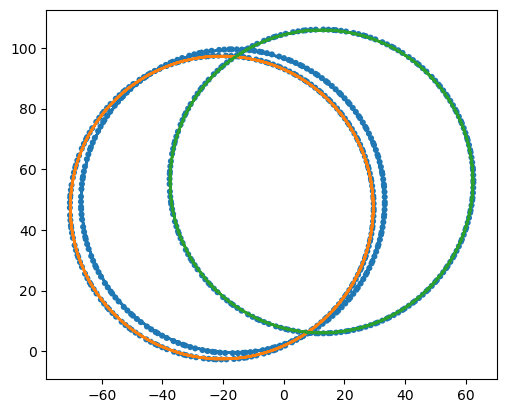

Average Reward:  0.0
Epoch 1/32, loss = 581.258179
Epoch 2/32, loss = 559.656616
Epoch 3/32, loss = 519.620239
Epoch 4/32, loss = 365.054718
Epoch 5/32, loss = 413.491394
Epoch 6/32, loss = 193.638885
Epoch 7/32, loss = 630.422424
Epoch 8/32, loss = 353.844116
Epoch 9/32, loss = 333.226257
Epoch 10/32, loss = 131.034882
Epoch 11/32, loss = 346.220245
Epoch 12/32, loss = 273.119873
Epoch 13/32, loss = 216.980301
Epoch 14/32, loss = 188.064667
Epoch 15/32, loss = 395.220459
Epoch 16/32, loss = 193.278412
Epoch 17/32, loss = 230.197449
Epoch 18/32, loss = 319.087158
Epoch 19/32, loss = 214.931641
Epoch 20/32, loss = 210.402176
Epoch 21/32, loss = 355.479095
Epoch 22/32, loss = 432.644806
Epoch 23/32, loss = 275.658997
Epoch 24/32, loss = 318.721985
Epoch 25/32, loss = 413.580902
Epoch 26/32, loss = 214.597351
Epoch 27/32, loss = 179.991364
Epoch 28/32, loss = 177.851868
Epoch 29/32, loss = 246.749207
Epoch 30/32, loss = 385.097778
Epoch 31/32, loss = 318.584961
Epoch 32/32, loss = 413.016

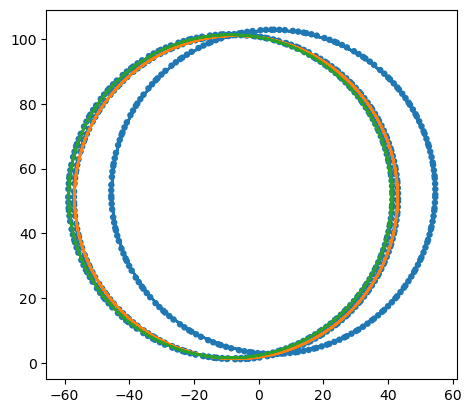

Average Reward:  0.0
Epoch 1/32, loss = 1635.748047
Epoch 2/32, loss = 1034.630615
Epoch 3/32, loss = 940.129456
Epoch 4/32, loss = 889.028809
Epoch 5/32, loss = 1108.588379
Epoch 6/32, loss = 897.539062
Epoch 7/32, loss = 849.103516
Epoch 8/32, loss = 513.552612
Epoch 9/32, loss = 787.836365
Epoch 10/32, loss = 725.831543
Epoch 11/32, loss = 564.344482
Epoch 12/32, loss = 1278.302490
Epoch 13/32, loss = 716.948303
Epoch 14/32, loss = 990.103821
Epoch 15/32, loss = 500.827942
Epoch 16/32, loss = 781.173462
Epoch 17/32, loss = 552.347290
Epoch 18/32, loss = 1115.001831
Epoch 19/32, loss = 740.454529
Epoch 20/32, loss = 778.062134
Epoch 21/32, loss = 639.953796
Epoch 22/32, loss = 546.424133
Epoch 23/32, loss = 632.133057
Epoch 24/32, loss = 957.260742
Epoch 25/32, loss = 652.453735
Epoch 26/32, loss = 821.692871
Epoch 27/32, loss = 560.786316
Epoch 28/32, loss = 814.488892
Epoch 29/32, loss = 626.038696
Epoch 30/32, loss = 1140.431152
Epoch 31/32, loss = 845.708679
Epoch 32/32, loss = 2

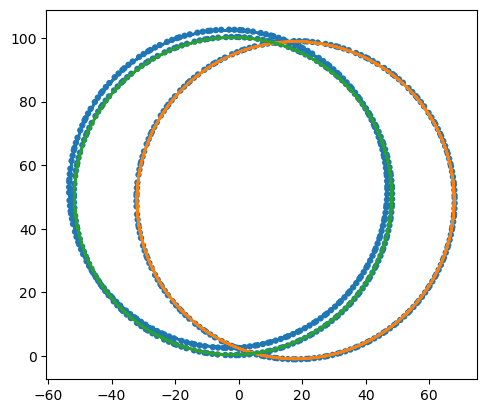

Average Reward:  0.0
Epoch 1/32, loss = 681.550537
Epoch 2/32, loss = 404.895691
Epoch 3/32, loss = 256.746094
Epoch 4/32, loss = 307.523987
Epoch 5/32, loss = 348.396484
Epoch 6/32, loss = 313.598480
Epoch 7/32, loss = 87.155144
Epoch 8/32, loss = 276.966400
Epoch 9/32, loss = 70.668205
Epoch 10/32, loss = 112.373932
Epoch 11/32, loss = 61.889004
Epoch 12/32, loss = 95.569519
Epoch 13/32, loss = 164.763016
Epoch 14/32, loss = 151.951782
Epoch 15/32, loss = 223.076767
Epoch 16/32, loss = 119.131058
Epoch 17/32, loss = 120.205147
Epoch 18/32, loss = 227.734375
Epoch 19/32, loss = 314.983704
Epoch 20/32, loss = 113.696167
Epoch 21/32, loss = 152.284027
Epoch 22/32, loss = 240.345612
Epoch 23/32, loss = 155.087555
Epoch 24/32, loss = 169.344696
Epoch 25/32, loss = 174.991516
Epoch 26/32, loss = 168.161896
Epoch 27/32, loss = 139.096924
Epoch 28/32, loss = 100.417572
Epoch 29/32, loss = 119.978012
Epoch 30/32, loss = 197.727509
Epoch 31/32, loss = 92.789436
Epoch 32/32, loss = 112.320282
S

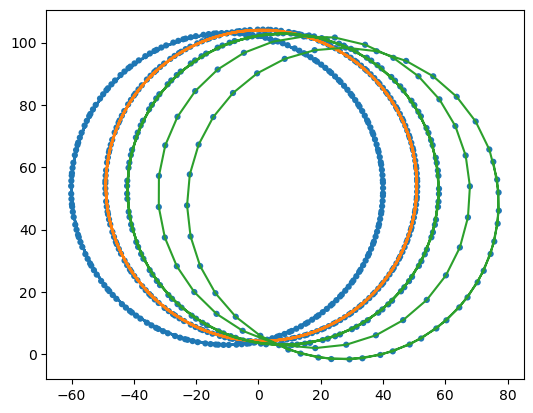

Average Reward:  0.0
Epoch 1/32, loss = 1176.341309
Epoch 2/32, loss = 645.588806
Epoch 3/32, loss = 248.692688
Epoch 4/32, loss = 236.821320
Epoch 5/32, loss = 117.273392
Epoch 6/32, loss = 259.687866
Epoch 7/32, loss = 269.094696
Epoch 8/32, loss = 126.104103
Epoch 9/32, loss = 119.736343
Epoch 10/32, loss = 192.463989
Epoch 11/32, loss = 117.338577
Epoch 12/32, loss = 130.409256
Epoch 13/32, loss = 69.665070
Epoch 14/32, loss = 51.195972
Epoch 15/32, loss = 87.750992
Epoch 16/32, loss = 99.624268
Epoch 17/32, loss = 63.757454
Epoch 18/32, loss = 168.517792
Epoch 19/32, loss = 164.348343
Epoch 20/32, loss = 70.685135
Epoch 21/32, loss = 157.210449
Epoch 22/32, loss = 113.217461
Epoch 23/32, loss = 102.296013
Epoch 24/32, loss = 192.745529
Epoch 25/32, loss = 183.902802
Epoch 26/32, loss = 87.776062
Epoch 27/32, loss = 32.333839
Epoch 28/32, loss = 142.535461
Epoch 29/32, loss = 64.482613
Epoch 30/32, loss = 62.824718
Epoch 31/32, loss = 194.116470
Epoch 32/32, loss = 114.379333
Saved

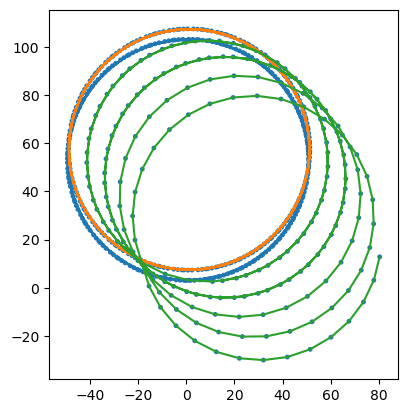

Average Reward:  0.0
Epoch 1/32, loss = 758.799683
Epoch 2/32, loss = 521.854309
Epoch 3/32, loss = 367.624603
Epoch 4/32, loss = 353.184052
Epoch 5/32, loss = 231.905792
Epoch 6/32, loss = 167.324219
Epoch 7/32, loss = 143.901703
Epoch 8/32, loss = 200.426132
Epoch 9/32, loss = 132.271774
Epoch 10/32, loss = 223.793427
Epoch 11/32, loss = 141.490082
Epoch 12/32, loss = 117.469955
Epoch 13/32, loss = 89.520020
Epoch 14/32, loss = 165.416870
Epoch 15/32, loss = 211.333038
Epoch 16/32, loss = 279.872803
Epoch 17/32, loss = 176.274231
Epoch 18/32, loss = 70.079483
Epoch 19/32, loss = 99.657562
Epoch 20/32, loss = 65.687813
Epoch 21/32, loss = 207.256592
Epoch 22/32, loss = 95.047050
Epoch 23/32, loss = 181.773010
Epoch 24/32, loss = 176.308655
Epoch 25/32, loss = 181.150925
Epoch 26/32, loss = 109.713135
Epoch 27/32, loss = 178.270935
Epoch 28/32, loss = 78.437347
Epoch 29/32, loss = 202.890533
Epoch 30/32, loss = 188.580811
Epoch 31/32, loss = 114.472626
Epoch 32/32, loss = 40.006802
Sav

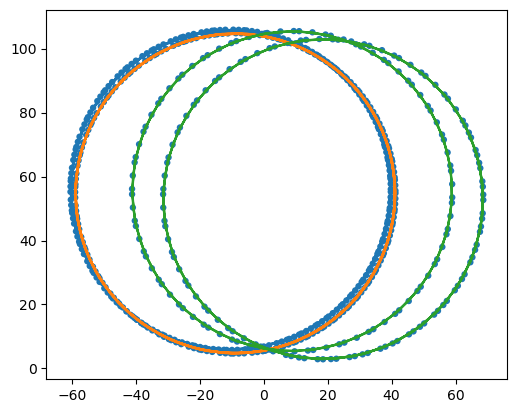

Average Reward:  0.0
Epoch 1/32, loss = 788.203003
Epoch 2/32, loss = 1533.469482
Epoch 3/32, loss = 791.999878
Epoch 4/32, loss = 718.215088
Epoch 5/32, loss = 703.376465
Epoch 6/32, loss = 273.257446
Epoch 7/32, loss = 402.190002
Epoch 8/32, loss = 528.926025
Epoch 9/32, loss = 271.575897
Epoch 10/32, loss = 488.152374
Epoch 11/32, loss = 178.999084
Epoch 12/32, loss = 363.542938
Epoch 13/32, loss = 241.186279
Epoch 14/32, loss = 250.390015
Epoch 15/32, loss = 171.299194
Epoch 16/32, loss = 332.201233
Epoch 17/32, loss = 186.969986
Epoch 18/32, loss = 254.727982
Epoch 19/32, loss = 150.429733
Epoch 20/32, loss = 364.578979
Epoch 21/32, loss = 162.789551
Epoch 22/32, loss = 127.808624
Epoch 23/32, loss = 76.610092
Epoch 24/32, loss = 120.761314
Epoch 25/32, loss = 67.301239
Epoch 26/32, loss = 288.622253
Epoch 27/32, loss = 419.998840
Epoch 28/32, loss = 519.693970
Epoch 29/32, loss = 232.009247
Epoch 30/32, loss = 159.859863
Epoch 31/32, loss = 269.300110
Epoch 32/32, loss = 312.6430

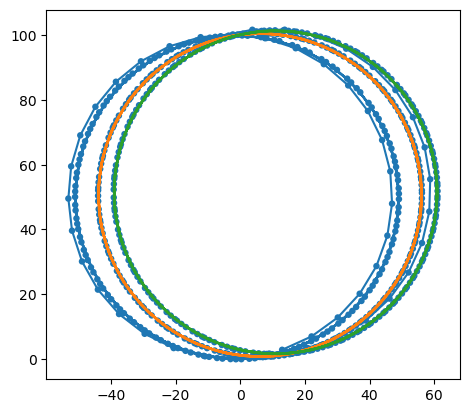

Average Reward:  0.0
Epoch 1/32, loss = 1478.519043
Epoch 2/32, loss = 982.847900
Epoch 3/32, loss = 715.627380
Epoch 4/32, loss = 293.832520
Epoch 5/32, loss = 929.519531
Epoch 6/32, loss = 419.661682
Epoch 7/32, loss = 455.228851
Epoch 8/32, loss = 351.263672
Epoch 9/32, loss = 437.239746
Epoch 10/32, loss = 198.650909
Epoch 11/32, loss = 157.234818
Epoch 12/32, loss = 517.880676
Epoch 13/32, loss = 81.411186
Epoch 14/32, loss = 201.681305
Epoch 15/32, loss = 153.673157
Epoch 16/32, loss = 395.913177
Epoch 17/32, loss = 149.448074
Epoch 18/32, loss = 370.950012
Epoch 19/32, loss = 196.450958
Epoch 20/32, loss = 71.972893
Epoch 21/32, loss = 197.780457
Epoch 22/32, loss = 293.507690
Epoch 23/32, loss = 396.577637
Epoch 24/32, loss = 102.444992
Epoch 25/32, loss = 105.091385
Epoch 26/32, loss = 88.466866
Epoch 27/32, loss = 169.074081
Epoch 28/32, loss = 350.053833
Epoch 29/32, loss = 291.935791
Epoch 30/32, loss = 98.095627
Epoch 31/32, loss = 121.520721
Epoch 32/32, loss = 36.994446


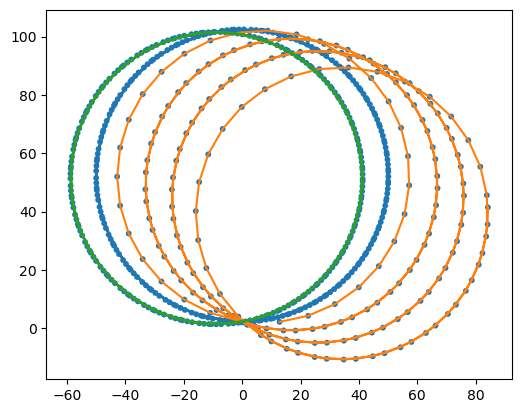

Average Reward:  0.0
Epoch 1/32, loss = 1473.153564
Epoch 2/32, loss = 787.950134
Epoch 3/32, loss = 576.905396
Epoch 4/32, loss = 599.228699
Epoch 5/32, loss = 625.604614
Epoch 6/32, loss = 408.206818
Epoch 7/32, loss = 141.491730
Epoch 8/32, loss = 659.606262
Epoch 9/32, loss = 218.695694
Epoch 10/32, loss = 264.687347
Epoch 11/32, loss = 301.444244
Epoch 12/32, loss = 612.051331
Epoch 13/32, loss = 536.676392
Epoch 14/32, loss = 303.845764
Epoch 15/32, loss = 445.912109
Epoch 16/32, loss = 222.868240
Epoch 17/32, loss = 563.338684
Epoch 18/32, loss = 347.211548
Epoch 19/32, loss = 90.216896
Epoch 20/32, loss = 520.330566
Epoch 21/32, loss = 127.744911
Epoch 22/32, loss = 187.069244
Epoch 23/32, loss = 229.124054
Epoch 24/32, loss = 505.398804
Epoch 25/32, loss = 436.073059
Epoch 26/32, loss = 405.846436
Epoch 27/32, loss = 426.430298
Epoch 28/32, loss = 485.254517
Epoch 29/32, loss = 262.028961
Epoch 30/32, loss = 321.023987
Epoch 31/32, loss = 367.867767
Epoch 32/32, loss = 358.739

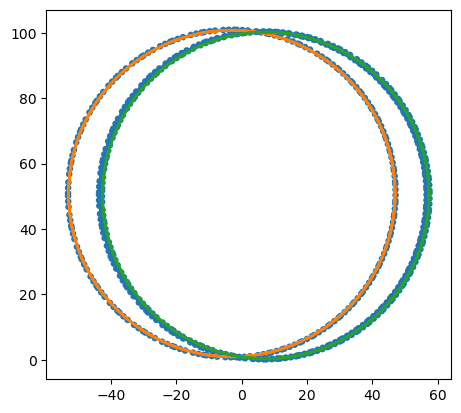

Average Reward:  0.0
Epoch 1/32, loss = 1857.850098
Epoch 2/32, loss = 1631.884521
Epoch 3/32, loss = 919.916565
Epoch 4/32, loss = 1022.461182
Epoch 5/32, loss = 1800.209961
Epoch 6/32, loss = 1618.221558
Epoch 7/32, loss = 909.354370
Epoch 8/32, loss = 1075.727051
Epoch 9/32, loss = 968.747253
Epoch 10/32, loss = 1209.989746
Epoch 11/32, loss = 1292.377441
Epoch 12/32, loss = 1001.496887
Epoch 13/32, loss = 877.510376
Epoch 14/32, loss = 1005.272339
Epoch 15/32, loss = 1570.842041
Epoch 16/32, loss = 1476.474365
Epoch 17/32, loss = 1518.684082
Epoch 18/32, loss = 1571.060425
Epoch 19/32, loss = 960.664429
Epoch 20/32, loss = 1675.401489
Epoch 21/32, loss = 1123.319946
Epoch 22/32, loss = 1047.170532
Epoch 23/32, loss = 692.654175
Epoch 24/32, loss = 1493.697998
Epoch 25/32, loss = 1321.504395
Epoch 26/32, loss = 634.072754
Epoch 27/32, loss = 1457.942261
Epoch 28/32, loss = 1994.380981
Epoch 29/32, loss = 1011.834290
Epoch 30/32, loss = 976.916748
Epoch 31/32, loss = 740.484619
Epoch

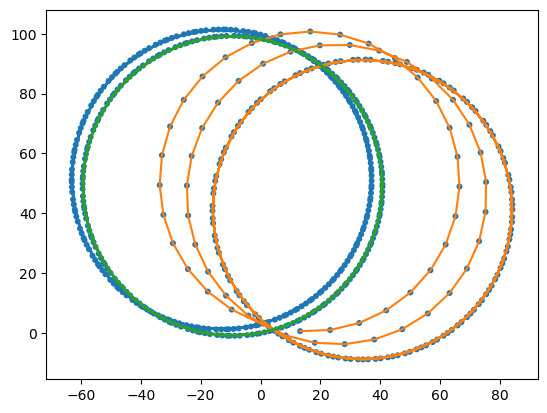

Average Reward:  0.0
Epoch 1/32, loss = 1735.601074
Epoch 2/32, loss = 1269.416992
Epoch 3/32, loss = 1280.303711
Epoch 4/32, loss = 1332.575317
Epoch 5/32, loss = 953.398499
Epoch 6/32, loss = 929.589233
Epoch 7/32, loss = 580.863647
Epoch 8/32, loss = 313.212341
Epoch 9/32, loss = 1021.480164
Epoch 10/32, loss = 505.930023
Epoch 11/32, loss = 284.537109
Epoch 12/32, loss = 353.370789
Epoch 13/32, loss = 751.388977
Epoch 14/32, loss = 958.615967
Epoch 15/32, loss = 543.667664
Epoch 16/32, loss = 512.146912
Epoch 17/32, loss = 543.141235
Epoch 18/32, loss = 696.355774
Epoch 19/32, loss = 244.089844
Epoch 20/32, loss = 627.983215
Epoch 21/32, loss = 403.380127
Epoch 22/32, loss = 553.709473
Epoch 23/32, loss = 69.714729
Epoch 24/32, loss = 968.562378
Epoch 25/32, loss = 502.776123
Epoch 26/32, loss = 958.019348
Epoch 27/32, loss = 325.398987
Epoch 28/32, loss = 427.907349
Epoch 29/32, loss = 287.909912
Epoch 30/32, loss = 652.543213
Epoch 31/32, loss = 332.941467
Epoch 32/32, loss = 263

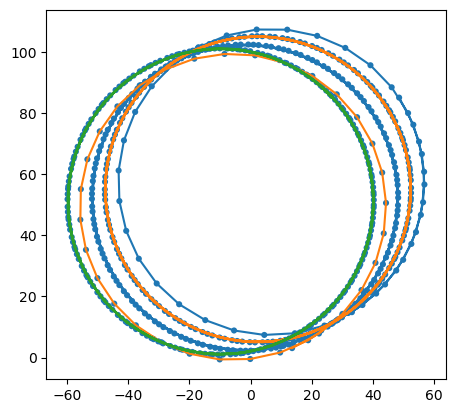

Average Reward:  0.0
Epoch 1/32, loss = 2338.430664
Epoch 2/32, loss = 1419.966553
Epoch 3/32, loss = 693.893188
Epoch 4/32, loss = 389.134186
Epoch 5/32, loss = 313.003510
Epoch 6/32, loss = 312.479065
Epoch 7/32, loss = 318.768738
Epoch 8/32, loss = 253.069092
Epoch 9/32, loss = 383.556702
Epoch 10/32, loss = 400.992798
Epoch 11/32, loss = 150.196533
Epoch 12/32, loss = 136.602661
Epoch 13/32, loss = 445.872742
Epoch 14/32, loss = 437.549622
Epoch 15/32, loss = 113.241028
Epoch 16/32, loss = 97.732155
Epoch 17/32, loss = 308.939880
Epoch 18/32, loss = 80.180199
Epoch 19/32, loss = 100.776260
Epoch 20/32, loss = 196.701096
Epoch 21/32, loss = 317.877960
Epoch 22/32, loss = 571.164185
Epoch 23/32, loss = 51.122124
Epoch 24/32, loss = 220.157227
Epoch 25/32, loss = 161.196808
Epoch 26/32, loss = 162.935211
Epoch 27/32, loss = 554.065063
Epoch 28/32, loss = 442.388367
Epoch 29/32, loss = 334.564758
Epoch 30/32, loss = 245.414169
Epoch 31/32, loss = 338.743835
Epoch 32/32, loss = 916.1695

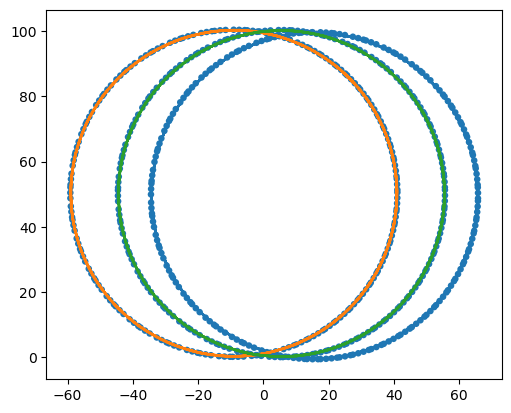

Average Reward:  0.0
Epoch 1/32, loss = 2423.977051
Epoch 2/32, loss = 1257.353149
Epoch 3/32, loss = 649.553711
Epoch 4/32, loss = 482.457428
Epoch 5/32, loss = 738.298279
Epoch 6/32, loss = 501.789307
Epoch 7/32, loss = 660.952148
Epoch 8/32, loss = 262.857849
Epoch 9/32, loss = 247.289032
Epoch 10/32, loss = 353.107361
Epoch 11/32, loss = 748.381836
Epoch 12/32, loss = 222.180191
Epoch 13/32, loss = 319.791504
Epoch 14/32, loss = 314.705566
Epoch 15/32, loss = 348.850830
Epoch 16/32, loss = 674.520142
Epoch 17/32, loss = 272.053406
Epoch 18/32, loss = 413.329224
Epoch 19/32, loss = 217.276718
Epoch 20/32, loss = 183.788971
Epoch 21/32, loss = 382.705780
Epoch 22/32, loss = 179.495209
Epoch 23/32, loss = 268.982025
Epoch 24/32, loss = 349.832764
Epoch 25/32, loss = 648.864014
Epoch 26/32, loss = 449.136169
Epoch 27/32, loss = 145.627045
Epoch 28/32, loss = 134.424927
Epoch 29/32, loss = 168.139328
Epoch 30/32, loss = 87.643318
Epoch 31/32, loss = 206.247955
Epoch 32/32, loss = 293.96

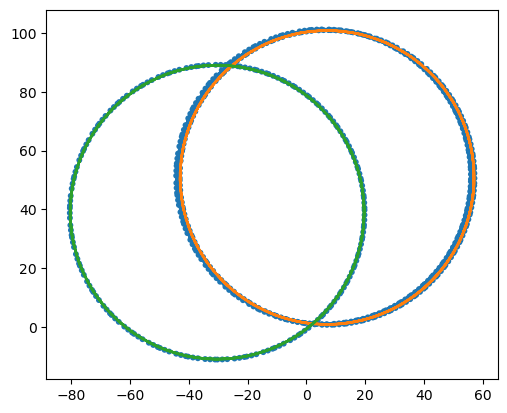

Average Reward:  0.0
Epoch 1/32, loss = 1496.673462
Epoch 2/32, loss = 864.185059
Epoch 3/32, loss = 771.488525
Epoch 4/32, loss = 869.569946
Epoch 5/32, loss = 534.606689
Epoch 6/32, loss = 627.022034
Epoch 7/32, loss = 441.749756
Epoch 8/32, loss = 479.620483
Epoch 9/32, loss = 524.649475
Epoch 10/32, loss = 206.164978
Epoch 11/32, loss = 344.496094
Epoch 12/32, loss = 601.481140
Epoch 13/32, loss = 489.678894
Epoch 14/32, loss = 261.990753
Epoch 15/32, loss = 257.167236
Epoch 16/32, loss = 121.950485
Epoch 17/32, loss = 566.418457
Epoch 18/32, loss = 669.245605
Epoch 19/32, loss = 637.054749
Epoch 20/32, loss = 141.395660
Epoch 21/32, loss = 219.473267
Epoch 22/32, loss = 378.731445
Epoch 23/32, loss = 265.743896
Epoch 24/32, loss = 1004.517700
Epoch 25/32, loss = 447.328949
Epoch 26/32, loss = 643.987915
Epoch 27/32, loss = 876.836548
Epoch 28/32, loss = 174.949707
Epoch 29/32, loss = 355.711121
Epoch 30/32, loss = 549.670654
Epoch 31/32, loss = 405.073914
Epoch 32/32, loss = 414.5

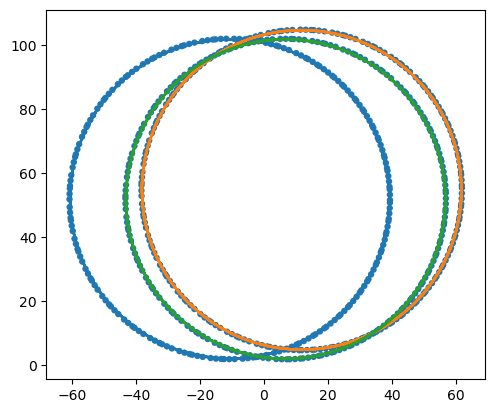

Average Reward:  0.0
Epoch 1/32, loss = 3490.017090
Epoch 2/32, loss = 2136.463379
Epoch 3/32, loss = 1260.835205
Epoch 4/32, loss = 1423.279297
Epoch 5/32, loss = 1577.168701
Epoch 6/32, loss = 2414.797852
Epoch 7/32, loss = 1256.043457
Epoch 8/32, loss = 1740.985107
Epoch 9/32, loss = 2449.114258
Epoch 10/32, loss = 834.922424
Epoch 11/32, loss = 270.289368
Epoch 12/32, loss = 2300.829590
Epoch 13/32, loss = 599.630798
Epoch 14/32, loss = 729.162720
Epoch 15/32, loss = 3419.040039
Epoch 16/32, loss = 2001.994751
Epoch 17/32, loss = 989.187134
Epoch 18/32, loss = 750.518860
Epoch 19/32, loss = 1343.259277
Epoch 20/32, loss = 540.695679
Epoch 21/32, loss = 1709.719727
Epoch 22/32, loss = 2093.584229
Epoch 23/32, loss = 1029.648438
Epoch 24/32, loss = 1430.993286
Epoch 25/32, loss = 1240.857422
Epoch 26/32, loss = 749.955627
Epoch 27/32, loss = 391.129578
Epoch 28/32, loss = 568.772949
Epoch 29/32, loss = 831.056519
Epoch 30/32, loss = 1644.314209
Epoch 31/32, loss = 1286.968750
Epoch 3

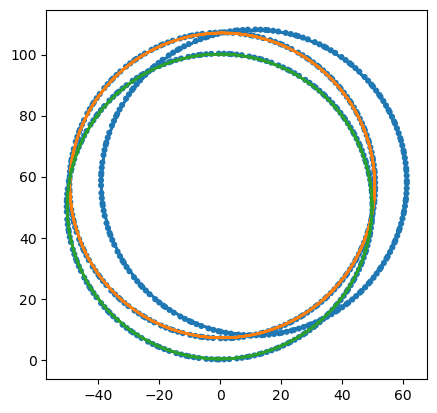

Average Reward:  0.0
Epoch 1/32, loss = 2002.754517
Epoch 2/32, loss = 1136.277710
Epoch 3/32, loss = 1095.559082
Epoch 4/32, loss = 1036.772583
Epoch 5/32, loss = 609.206787
Epoch 6/32, loss = 642.864258
Epoch 7/32, loss = 773.054688
Epoch 8/32, loss = 647.478516
Epoch 9/32, loss = 639.462158
Epoch 10/32, loss = 653.063782
Epoch 11/32, loss = 418.112671
Epoch 12/32, loss = 597.504761
Epoch 13/32, loss = 350.962830
Epoch 14/32, loss = 519.986938
Epoch 15/32, loss = 204.215454
Epoch 16/32, loss = 577.729980
Epoch 17/32, loss = 750.046570
Epoch 18/32, loss = 577.830994
Epoch 19/32, loss = 507.689941
Epoch 20/32, loss = 225.307541
Epoch 21/32, loss = 222.628052
Epoch 22/32, loss = 403.876160
Epoch 23/32, loss = 767.127808
Epoch 24/32, loss = 231.460342
Epoch 25/32, loss = 676.156250
Epoch 26/32, loss = 228.725555
Epoch 27/32, loss = 326.454712
Epoch 28/32, loss = 521.005249
Epoch 29/32, loss = 316.098389
Epoch 30/32, loss = 633.139893
Epoch 31/32, loss = 372.153412
Epoch 32/32, loss = 857

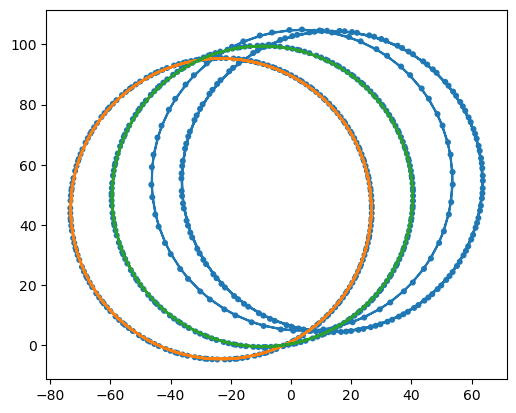

Average Reward:  0.0
Epoch 1/32, loss = 4334.595703
Epoch 2/32, loss = 2822.556641
Epoch 3/32, loss = 4022.950684
Epoch 4/32, loss = 3772.314453
Epoch 5/32, loss = 1625.818848
Epoch 6/32, loss = 2261.021973
Epoch 7/32, loss = 2528.536621
Epoch 8/32, loss = 996.574280
Epoch 9/32, loss = 1184.232666
Epoch 10/32, loss = 3315.994873
Epoch 11/32, loss = 2252.708984
Epoch 12/32, loss = 1644.553711
Epoch 13/32, loss = 1779.785522
Epoch 14/32, loss = 2844.111084
Epoch 15/32, loss = 1794.350220
Epoch 16/32, loss = 2520.379395
Epoch 17/32, loss = 2242.413330
Epoch 18/32, loss = 1929.772461
Epoch 19/32, loss = 1769.757935
Epoch 20/32, loss = 1484.154297
Epoch 21/32, loss = 2324.837646
Epoch 22/32, loss = 1511.422974
Epoch 23/32, loss = 2703.140625
Epoch 24/32, loss = 1063.675781
Epoch 25/32, loss = 2702.621582
Epoch 26/32, loss = 353.136414
Epoch 27/32, loss = 2939.104004
Epoch 28/32, loss = 1054.482300
Epoch 29/32, loss = 284.690674
Epoch 30/32, loss = 4831.217773
Epoch 31/32, loss = 1295.454468

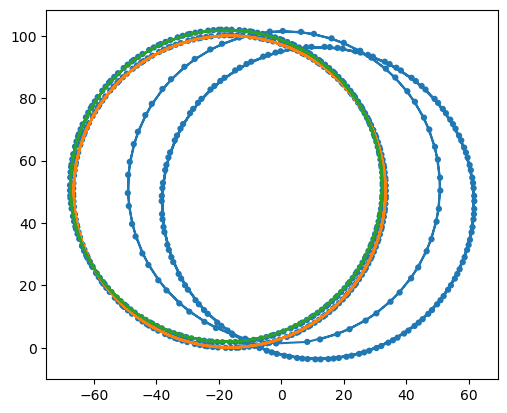

Average Reward:  0.0
Epoch 1/32, loss = 14599.424805
Epoch 2/32, loss = 5761.319824
Epoch 3/32, loss = 6000.413574
Epoch 4/32, loss = 3184.112549
Epoch 5/32, loss = 4659.829590
Epoch 6/32, loss = 4004.395020
Epoch 7/32, loss = 3117.228027
Epoch 8/32, loss = 4349.295410
Epoch 9/32, loss = 3537.381836
Epoch 10/32, loss = 4775.035156
Epoch 11/32, loss = 10561.060547
Epoch 12/32, loss = 3150.950439
Epoch 13/32, loss = 4411.038574
Epoch 14/32, loss = 3887.113281
Epoch 15/32, loss = 4911.570801
Epoch 16/32, loss = 2745.065430
Epoch 17/32, loss = 3855.655518
Epoch 18/32, loss = 2266.755859
Epoch 19/32, loss = 981.444092
Epoch 20/32, loss = 3773.397949
Epoch 21/32, loss = 3579.630371
Epoch 22/32, loss = 2418.542480
Epoch 23/32, loss = 1720.632324
Epoch 24/32, loss = 4845.713867
Epoch 25/32, loss = 2463.793701
Epoch 26/32, loss = 3007.722900
Epoch 27/32, loss = 2994.066650
Epoch 28/32, loss = 1951.284912
Epoch 29/32, loss = 1318.239624
Epoch 30/32, loss = 2617.694336
Epoch 31/32, loss = 3572.73

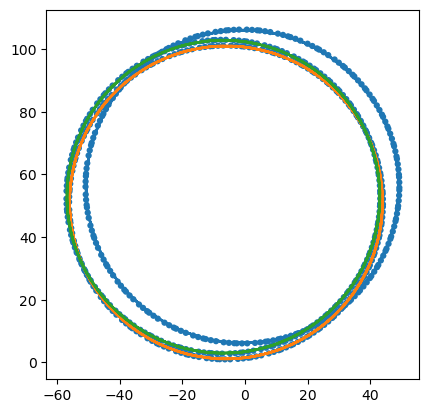

Average Reward:  0.0
Epoch 1/32, loss = 9225.484375
Epoch 2/32, loss = 5986.917969
Epoch 3/32, loss = 7338.636719
Epoch 4/32, loss = 2742.179932
Epoch 5/32, loss = 2609.849121
Epoch 6/32, loss = 3118.746582
Epoch 7/32, loss = 3862.858887
Epoch 8/32, loss = 1292.127563
Epoch 9/32, loss = 4220.596680
Epoch 10/32, loss = 5517.987305
Epoch 11/32, loss = 2773.995605
Epoch 12/32, loss = 4173.852539
Epoch 13/32, loss = 2007.128906
Epoch 14/32, loss = 3125.134277
Epoch 15/32, loss = 4074.288574
Epoch 16/32, loss = 2532.241211
Epoch 17/32, loss = 4489.092773
Epoch 18/32, loss = 4449.811035
Epoch 19/32, loss = 2337.513184
Epoch 20/32, loss = 3646.747070
Epoch 21/32, loss = 3021.380859
Epoch 22/32, loss = 4254.432129
Epoch 23/32, loss = 2142.591309
Epoch 24/32, loss = 3026.360352
Epoch 25/32, loss = 4710.328125
Epoch 26/32, loss = 3349.272461
Epoch 27/32, loss = 1109.698486
Epoch 28/32, loss = 3751.644775
Epoch 29/32, loss = 4109.245605
Epoch 30/32, loss = 2662.358887
Epoch 31/32, loss = 3887.562

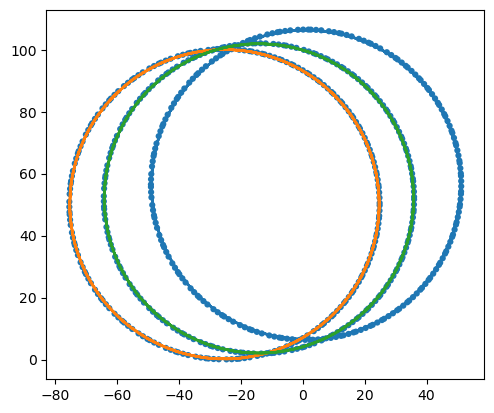

Average Reward:  0.0
Epoch 1/32, loss = 3294.310791
Epoch 2/32, loss = 3270.156982
Epoch 3/32, loss = 1119.996826
Epoch 4/32, loss = 1861.127563
Epoch 5/32, loss = 3081.373535
Epoch 6/32, loss = 2740.067383
Epoch 7/32, loss = 2756.797119
Epoch 8/32, loss = 749.664612
Epoch 9/32, loss = 1860.218262
Epoch 10/32, loss = 977.446899
Epoch 11/32, loss = 1015.354370
Epoch 12/32, loss = 1684.921631
Epoch 13/32, loss = 1406.687134
Epoch 14/32, loss = 2425.760010
Epoch 15/32, loss = 837.477783
Epoch 16/32, loss = 452.240112
Epoch 17/32, loss = 279.648621
Epoch 18/32, loss = 953.346436
Epoch 19/32, loss = 2156.464111
Epoch 20/32, loss = 586.807190
Epoch 21/32, loss = 443.128906
Epoch 22/32, loss = 2139.023438
Epoch 23/32, loss = 819.967041
Epoch 24/32, loss = 756.701172
Epoch 25/32, loss = 244.820068
Epoch 26/32, loss = 677.178528
Epoch 27/32, loss = 543.220093
Epoch 28/32, loss = 844.445618
Epoch 29/32, loss = 3291.268066
Epoch 30/32, loss = 509.011078
Epoch 31/32, loss = 2292.241211
Epoch 32/32

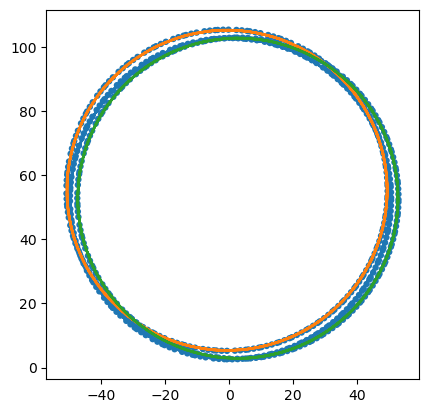

Average Reward:  0.0
Epoch 1/32, loss = 5228.998047
Epoch 2/32, loss = 3667.384277
Epoch 3/32, loss = 2432.364258
Epoch 4/32, loss = 3393.345215
Epoch 5/32, loss = 2105.360107
Epoch 6/32, loss = 1858.700195
Epoch 7/32, loss = 3518.425293
Epoch 8/32, loss = 947.134766
Epoch 9/32, loss = 3016.801514
Epoch 10/32, loss = 1634.908203
Epoch 11/32, loss = 3727.245605
Epoch 12/32, loss = 1534.575684
Epoch 13/32, loss = 2521.472656
Epoch 14/32, loss = 1570.181396
Epoch 15/32, loss = 2961.148926
Epoch 16/32, loss = 1536.750000
Epoch 17/32, loss = 1169.263794
Epoch 18/32, loss = 846.071594
Epoch 19/32, loss = 2430.887451
Epoch 20/32, loss = 1546.678833
Epoch 21/32, loss = 1516.126709
Epoch 22/32, loss = 1740.387817
Epoch 23/32, loss = 682.454102
Epoch 24/32, loss = 1516.324219
Epoch 25/32, loss = 1295.741821
Epoch 26/32, loss = 1186.197021
Epoch 27/32, loss = 1135.356201
Epoch 28/32, loss = 1500.246460
Epoch 29/32, loss = 913.992493
Epoch 30/32, loss = 1632.644287
Epoch 31/32, loss = 1405.089844


KeyboardInterrupt: 

In [28]:
N = 3
T = 200
key = jax.random.PRNGKey(0) 

batch_size = 128
num_epochs = 32

T_min = 0.05
T_0 = 20
decay = 0.1

# initalise the model
q_model = QNetwork(num_actions=num_actions)

dummy_frames = jnp.zeros((1, memory_length, n_s), dtype=jnp.float32)

optimizer = optax.adamw(
    learning_rate= 3e-4,
    weight_decay=1e-5
)

save_dir = "./CheckpointsN=" + str(N)
os.makedirs(save_dir, exist_ok=True)

key = jax.random.PRNGKey(0) 

# Initialize online network parameters

# New Network
finish = -1
online_params = q_model.init(key, dummy_frames)
target_params = update_target_network(online_params)
opt_state = optimizer.init(online_params)

# Load Network 

# finish = 15

# chk = load_checkpoint("CheckpointsN=" + str(N) + "/cycle_" + str(finish) + ".ckpt")
# online_params = chk["online_params"]
# target_params = chk["target_params"]
# opt_state = optimizer.init(online_params)

def train(key, online_params, target_params, opt_state, start, end):
    for cycle in range(start, end):

        epsilon = T_min + (T_0-T_min) * jnp.exp(-cycle/(end*decay))
  
        print(f"\n=== Training Cycle {cycle+1} ===")
        print(f"\n=== Epsilon = {epsilon} ===")


        key, sim_key, training_key = jax.random.split(key, 3)
        data = run_sim(sim_key, N, T, online_params, epsilon)
        
        
        plot_trajectory(data[4], data[5])
        
        print ("Average Reward: ", jnp.sum(data[2])/ (N*T))

        states, actions, rewards, next_states, terminals = prepare_data(data)
        
        online_params, opt_state, losses = train_for_epochs(
            training_key,
            online_params,
            target_params,
            opt_state,
            states,
            actions,
            rewards,
            next_states,
            terminals,
            batch_size=batch_size,
            num_epochs=num_epochs
        )

        jnp.save(save_dir + "/losses_cycle_" + str(cycle), jnp.array(losses))
        
        target_params = update_target_network(online_params)

        save_checkpoint(save_dir, online_params, target_params, opt_state, cycle)

train(key, online_params, target_params, opt_state, finish + 1, 100)

In [ ]:
visual_state = jax.random.bernoulli(key, p=0.5, shape=(1,n_s)).astype(jnp.float32)

print (visual_state)

q_values(target_params, visual_state, visual_state)

In [ ]:
visual_state = jnp.zeros((1,n_s))

q_values(target_params, visual_state, visual_state)

In [ ]:
visual_state = jnp.ones((1,n_s))

q_values(target_params, visual_state, visual_state)

In [ ]:
key = jax.random.PRNGKey(2) 

chk = load_checkpoint("CheckpointsN=3/cycle_200.ckpt")
online_params = chk["online_params"]
target_params = chk["target_params"]

n = 3
tMax = 1000

data = run_NN(key, n, tMax, target_params)

plot_trajectory(data[0], data[1])

produce_frames(data[0], data[1], data[2], data[3], n, tMax)




